# RoBERTa Tagalog MCD Analysis

This notebook evaluates uncertainty-aware inference for Symptom2Disease classification using `RoBERTa-Tagalog` with Monte Carlo Dropout (MCD).

## What This Notebook Gives You

- A reproducible evaluation pipeline with fixed random seed (`42`).
- Stratified fold-wise partitioning of the held-out test split.
- Predictive performance metrics (accuracy, precision, recall, F1).
- Uncertainty quality metrics (entropy, mutual information, calibration signals).
- Comparative analysis against baseline deterministic inference.

# 1. Project Setup

## Goal

Set up dependencies and authentication required to run the full evaluation pipeline end-to-end.

## Run Notes

- Run cells in order from top to bottom on a fresh kernel.
- This notebook checks disk space and halts when free space drops below 5 GB.
- GPU is optional; CPU execution is supported but slower.
- For automated environments, set `HF_TOKEN` before execution.

In [1]:
%pip install transformers torch numpy scipy pandas seaborn matplotlib scikit-learn tqdm datasets huggingface_hub

Note: you may need to restart the kernel to use updated packages.


# 2. `MonteCarloDropoutClassifier` Class Setup

## Reference: What This Class Does

This class provides batched MCD inference by reactivating dropout layers at inference time and aggregating predictions across multiple stochastic forward passes.

## Key Outputs Per Batch

- `predicted_class`: argmax class from mean probabilities.
- `confidence`: max class probability after averaging MC passes.
- `predictive_entropy`: total uncertainty from mean predictive distribution.
- `mutual_information`: epistemic uncertainty estimate (`H(E[p]) - E[H(p)]`).

## Why It Matters

This design lets you compare raw accuracy with uncertainty behavior, which is essential for risk-aware medical text classification workflows.

In [2]:
# Code from intern, refactored for safer and faster batched MC inference
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from scipy.stats import entropy


class MonteCarloDropoutClassifier:
    def __init__(
        self,
        model_path,
        n_iterations=50,
        inference_dropout_rate=0.05,
        device=None,
        max_length=256,
    ):
        self.n_iterations = n_iterations
        self.inference_dropout_rate = float(inference_dropout_rate)
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.max_length = max_length
        self._dropout_is_configured = False

        self.model = AutoModelForSequenceClassification.from_pretrained(model_path)
        self.tokenizer = AutoTokenizer.from_pretrained(model_path)
        self.model.to(self.device)
        self.model.eval()

    def set_inference_dropout_rate(self, dropout_rate):
        if not 0.0 <= float(dropout_rate) <= 1.0:
            raise ValueError(f"dropout_rate must be in [0, 1], got {dropout_rate}")
        self.inference_dropout_rate = float(dropout_rate)
        self._dropout_is_configured = False

    def enable_dropout_with_rate(self, dropout_rate=None):
        """
        Enable dropout layers with a specified rate (or use default).
        Keeps normalization layers in eval mode for stable MC Dropout inference.
        """
        if dropout_rate is None:
            dropout_rate = self.inference_dropout_rate

        for module in self.model.modules():
            if module.__class__.__name__.startswith("Dropout"):
                module.p = float(dropout_rate)
                module.train()
            elif "Norm" in module.__class__.__name__:
                module.eval()

        self._dropout_is_configured = True

    def _tokenize_batch(self, texts):
        return self.tokenizer(
            texts,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=self.max_length,
        ).to(self.device)

    def predict_batch_with_uncertainty(self, texts, return_all_predictions=False):
        if isinstance(texts, str):
            texts = [texts]
        if not texts:
            raise ValueError("texts must contain at least one sample")

        inputs = self._tokenize_batch(texts)

        if not self._dropout_is_configured:
            self.enable_dropout_with_rate(dropout_rate=self.inference_dropout_rate)

        all_predictions = []

        with torch.inference_mode():
            for _ in range(self.n_iterations):
                outputs = self.model(**inputs)
                probabilities = torch.softmax(outputs.logits, dim=-1)
                all_predictions.append(probabilities.detach().cpu().numpy())

        all_predictions = np.stack(all_predictions, axis=0)

        mean_probs = all_predictions.mean(axis=0)
        std_probs = all_predictions.std(axis=0)

        predicted_class = mean_probs.argmax(axis=-1)
        confidence = mean_probs.max(axis=-1)

        predictive_entropy = entropy(mean_probs, axis=-1)
        mutual_information = self.compute_mutual_information(all_predictions)

        output = {
            "predicted_class": predicted_class,
            "predicted_label": [self.model.config.id2label[int(idx)] for idx in predicted_class],
            "mean_probabilities": mean_probs,
            "std_probabilities": std_probs,
            "confidence": confidence,
            "predictive_entropy": predictive_entropy,
            "mutual_information": mutual_information,
        }

        if return_all_predictions:
            output["all_predictions"] = all_predictions

        return output

    def predict_with_uncertainty(self, text, return_all_predictions=True):
        return self.predict_batch_with_uncertainty(
            [text],
            return_all_predictions=return_all_predictions,
        )

    def compute_mutual_information(self, predictions):
        """
        Compute mutual information as measure of epistemic uncertainty.
        MI = H(E[p]) - E[H(p)]
        """
        expected_entropy = entropy(predictions, axis=-1).mean(axis=0)
        mean_probs = predictions.mean(axis=0)
        entropy_of_expected = entropy(mean_probs, axis=-1)
        return entropy_of_expected - expected_entropy

/home/notlath/Downloads/model-training-fil/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
from huggingface_hub import login

hf_token = os.getenv("HF_TOKEN")
if hf_token:
    login(token=hf_token, add_to_git_credential=True)
    print("HF login complete using HF_TOKEN.")
else:
    print("HF_TOKEN not found. Assuming this environment is already authenticated.")

HF_TOKEN not found. Assuming this environment is already authenticated.


# 3. Dataset Setup

## How-To: Prepare Data for Evaluation

This section loads the dataset, maps string labels to model-compatible IDs, applies a reproducible 70/15/15 split, and reports class distribution in the test split.

## Validation Checks Included

- Library version logging for reproducibility.
- Consistent global seeding (`set_seed`, NumPy, CUDA).
- Disk-space guard before heavy processing.
- Explicit class-count summary for inspection of label imbalance.

In [4]:
import shutil
import torch
import numpy as np
import transformers
import datasets as datasets_lib
from datasets import load_dataset
from transformers import set_seed, AutoModelForSequenceClassification, AutoTokenizer


def log_disk_space_or_halt(min_free_gb=5):
    total, used, free = shutil.disk_usage("/")
    print(f"Disk space — Free: {free // (2**30)} GB / Total: {total // (2**30)} GB")
    free_gb = free // (2**30)
    if free_gb < min_free_gb:
        raise RuntimeWarning(
            f"Low disk space: {free_gb} GB free (< {min_free_gb} GB). Halting to avoid storage exhaustion."
        )
    return free_gb


def normalize_dataset_label_to_id(label, label2id_map, id2label_map):
    """Convert dataset label values (int/str) into stable integer class ids."""
    if isinstance(label, (int, np.integer)):
        return int(label)

    if isinstance(label, str):
        if label.startswith("LABEL_") and label[6:].isdigit():
            return int(label[6:])
        if label.isdigit():
            return int(label)
        if label in label2id_map:
            return int(label2id_map[label])

        # Handle class-name labels robustly even if id2label keys are strings.
        for k, v in id2label_map.items():
            if v == label:
                return int(k)

    raise ValueError(
        f"Could not normalize dataset label {label!r}. "
        "Expected int, digit string, LABEL_k, or known class name."
    )


set_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"transformers=={transformers.__version__}")
print(f"datasets=={datasets_lib.__version__}")
print(f"torch=={torch.__version__}")

# Load the model first to get the CORRECT label mapping
model_path = "notlath/RoBERTa-Tagalog-base-Symptom2Disease_WITH-DROPOUT-42"
model_config = AutoModelForSequenceClassification.from_pretrained(model_path).config
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Use the model's label mapping
label2id = model_config.label2id
id2label = model_config.id2label

print(f"\nUsing model label mapping with {len(label2id)} classes")
print(f"Label mapping: {id2label}")

full_dataset = load_dataset("notlath/fil_dataset")
log_disk_space_or_halt(min_free_gb=5)

# Convert labels to integers using model mapping
def convert_labels_to_ids(example):
    label_id = normalize_dataset_label_to_id(example["label"], label2id, id2label)
    return {
        "text": example["text"],
        "labels": label_id,
    }

# Use pre-existing splits directly — no resplitting needed
dataset = {
    "train": full_dataset["train"].map(convert_labels_to_ids, remove_columns=["label"]),
    "validation": full_dataset["validation"].map(convert_labels_to_ids, remove_columns=["label"]),
    "test": full_dataset["test"].map(convert_labels_to_ids, remove_columns=["label"]),
}

print(f"\nDataset Splits:")
print(f"   Train: {len(dataset['train'])} samples")
print(f"   Validation: {len(dataset['validation'])} samples")
print(f"   Test: {len(dataset['test'])} samples")

from collections import Counter

test_labels = dataset["test"]["labels"]
label_counts = Counter(test_labels)
print(f"\nTest Set Class Distribution:")
for label_id, count in sorted(label_counts.items()):
    label_name = id2label.get(label_id, id2label.get(str(label_id), str(label_id)))
    print(f"   {str(label_name):15s}: {count} samples")

transformers==5.2.0
datasets==4.6.1
torch==2.10.0+cu128


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 545.12it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              



Using model label mapping with 6 classes
Label mapping: {0: 'Dengue', 1: 'Diarrhea', 2: 'Influenza', 3: 'Measles', 4: 'Pneumonia', 5: 'Typhoid'}
Disk space — Free: 6 GB / Total: 200 GB


Map: 100%|██████████| 900/900 [00:00<00:00, 9818.13 examples/s]


Dataset Splits:
   Train: 4200 samples
   Validation: 900 samples
   Test: 900 samples

Test Set Class Distribution:
   Dengue         : 150 samples
   Diarrhea       : 150 samples
   Influenza      : 150 samples
   Measles        : 150 samples
   Pneumonia      : 150 samples
   Typhoid        : 150 samples


# 4. Fold-Wise Evaluation Setup (Partitioned Test Set)

## Explanation

This section performs fold-wise analysis on the held-out test split using `StratifiedKFold` to preserve class balance across folds.

## Important Methodology Note

- This is **partitioned test-set evaluation** of a fixed trained model.
- It is useful for robustness and uncertainty consistency checks.
- It is not training-time cross-validation with per-fold retraining.

## Outputs

The section aggregates fold metrics (mean ± std), calibration statistics, and reliability-bin data for reporting.

In [5]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
from tqdm import tqdm


class MCDCrossValidator:
    def __init__(self, classifier, dataset, tokenizer, n_splits=5, batch_size=16):
        """
        Fold-wise partitioned evaluation for Monte Carlo Dropout on a fixed model.

        Note: This does not retrain per fold. It partitions a held-out set and reports
        stability/calibration behavior across folds.
        """
        self.classifier = classifier
        self.dataset = dataset
        self.tokenizer = tokenizer
        self.n_splits = n_splits
        self.batch_size = batch_size
        self.results = []

    def evaluate_fold(self, fold_data):
        """Evaluate MCD on a single fold using batched inference."""
        texts = fold_data["text"]
        labels = np.array(fold_data["labels"])

        print(f"\nDIAGNOSTIC INFO:")
        print(f"   Fold data size: {len(texts)}")
        print(f"   Sample text: {texts[0][:100]}...")
        print(f"   Sample label ID (dataset): {labels[0]}")

        if hasattr(self.classifier.model.config, "id2label"):
            print(f"   Model has {len(self.classifier.model.config.id2label)} classes")
            print(f"   Model id2label sample: {list(self.classifier.model.config.id2label.items())[:3]}")

        all_predictions = []
        all_labels = []
        all_confidences = []
        all_uncertainties = []
        all_entropies = []
        all_texts = []

        for start in tqdm(range(0, len(texts), self.batch_size), desc="Evaluating fold (batched)"):
            end = min(start + self.batch_size, len(texts))
            batch_texts = texts[start:end]
            batch_labels = labels[start:end]

            result = self.classifier.predict_batch_with_uncertainty(batch_texts)

            predicted_batch = result["predicted_class"]
            confidence_batch = result["confidence"]
            mi_batch = result["mutual_information"]
            entropy_batch = result["predictive_entropy"]

            if start == 0:
                print("\n   Sample 0 (from first batch):")
                print(f"      True label ID: {batch_labels[0]}")
                print(f"      Predicted ID: {predicted_batch[0]}")
                print(
                    f"      Model's interpretation of true label: "
                    f"{self.classifier.model.config.id2label.get(int(batch_labels[0]), 'UNKNOWN')}"
                )
                print(f"      Model's prediction: {result['predicted_label'][0]}")

            all_predictions.extend(predicted_batch.tolist())
            all_labels.extend(batch_labels.tolist())
            all_confidences.extend(confidence_batch.tolist())
            all_uncertainties.extend(mi_batch.tolist())
            all_entropies.extend(entropy_batch.tolist())
            all_texts.extend(batch_texts)

        accuracy = accuracy_score(all_labels, all_predictions)
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0,
        )

        if accuracy < 0.5:
            print(f"\nLOW ACCURACY DETECTED: {accuracy:.4f}")
            print(f"   Unique true labels: {set(all_labels)}")
            print(f"   Unique predictions: {set(all_predictions)}")
            print(f"   Label range in dataset: {min(all_labels)} to {max(all_labels)}")
            print(f"   Prediction range: {min(all_predictions)} to {max(all_predictions)}")

        correct_predictions = np.array(all_predictions) == np.array(all_labels)
        avg_confidence_correct = (
            np.mean([all_confidences[i] for i in range(len(correct_predictions)) if correct_predictions[i]])
            if any(correct_predictions)
            else np.nan
        )
        avg_confidence_incorrect = (
            np.mean([all_confidences[i] for i in range(len(correct_predictions)) if not correct_predictions[i]])
            if not all(correct_predictions)
            else np.nan
        )

        avg_uncertainty_correct = (
            np.mean([all_uncertainties[i] for i in range(len(correct_predictions)) if correct_predictions[i]])
            if any(correct_predictions)
            else np.nan
        )
        avg_uncertainty_incorrect = (
            np.mean([all_uncertainties[i] for i in range(len(correct_predictions)) if not correct_predictions[i]])
            if not all(correct_predictions)
            else np.nan
        )

        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "mean_confidence": np.mean(all_confidences),
            "std_confidence": np.std(all_confidences),
            "mean_uncertainty": np.mean(all_uncertainties),
            "std_uncertainty": np.std(all_uncertainties),
            "mean_entropy": np.mean(all_entropies),
            "confidence_correct": avg_confidence_correct,
            "confidence_incorrect": avg_confidence_incorrect,
            "uncertainty_correct": avg_uncertainty_correct,
            "uncertainty_incorrect": avg_uncertainty_incorrect,
            "predictions": all_predictions,
            "labels": all_labels,
            "confidences": all_confidences,
            "uncertainties": all_uncertainties,
            "texts": all_texts,
        }

    def run_kfold_evaluation(self):
        """
        Run fold-wise partitioned evaluation on the held-out test set.

        Returns:
            dict with aggregated results across folds
        """
        log_disk_space_or_halt(min_free_gb=5)

        print(f"\n{'=' * 80}")
        print(
            f"Starting {self.n_splits}-Fold Partitioned Evaluation with Monte Carlo Dropout "
            f"(fixed model, no retraining)"
        )
        print(f"{'=' * 80}\n")

        if hasattr(self.dataset, "to_pandas"):
            dataset_df = self.dataset.to_pandas()
        else:
            dataset_df = pd.DataFrame({"text": self.dataset["text"], "labels": self.dataset["labels"]})

        labels = np.array(self.dataset["labels"])
        splitter = StratifiedKFold(n_splits=self.n_splits, shuffle=True, random_state=42)
        print("StratifiedKFold enabled — class distribution preserved across folds")
        split_iter = splitter.split(dataset_df, labels)

        fold_results = []

        for fold_idx, (_, test_idx) in enumerate(split_iter):
            print(f"\nFold {fold_idx + 1}/{self.n_splits}")
            print("-" * 80)

            fold_data = self.dataset.select(np.array(test_idx).tolist())
            fold_result = self.evaluate_fold(fold_data)
            fold_result["fold"] = fold_idx + 1
            fold_results.append(fold_result)

            print(f"\nFold {fold_idx + 1} Results:")
            print(f"   Accuracy: {fold_result['accuracy']:.4f}")
            print(f"   Precision: {fold_result['precision']:.4f}")
            print(f"   Recall: {fold_result['recall']:.4f}")
            print(f"   F1-Score: {fold_result['f1']:.4f}")
            print(f"   Mean Confidence: {fold_result['mean_confidence']:.4f} +/- {fold_result['std_confidence']:.4f}")
            print(f"   Mean Uncertainty (MI): {fold_result['mean_uncertainty']:.4f} +/- {fold_result['std_uncertainty']:.4f}")
            print(f"   Confidence (Correct): {fold_result['confidence_correct']:.4f}")
            print(f"   Confidence (Incorrect): {fold_result['confidence_incorrect']:.4f}")
            print(f"   Uncertainty (Correct): {fold_result['uncertainty_correct']:.4f}")
            print(f"   Uncertainty (Incorrect): {fold_result['uncertainty_incorrect']:.4f}")

            log_disk_space_or_halt(min_free_gb=5)

        aggregated = self._aggregate_results(fold_results)
        self.results = fold_results

        return aggregated, fold_results

    def _aggregate_results(self, fold_results):
        """Aggregate metrics across all folds, including calibration (ECE) and reliability data."""
        print(f"\n{'='*80}")
        print(f"AGGREGATED RESULTS ACROSS {self.n_splits} FOLDS")
        print(f"{'='*80}\n")

        metrics = ['accuracy', 'precision', 'recall', 'f1', 'mean_confidence', 'mean_uncertainty', 'mean_entropy',
                   'confidence_correct', 'confidence_incorrect',
                   'uncertainty_correct', 'uncertainty_incorrect']

        aggregated = {}
        nan_sensitive_metrics = {
            'confidence_correct',
            'confidence_incorrect',
            'uncertainty_correct',
            'uncertainty_incorrect',
        }
        for metric in metrics:
            values = np.array([fold[metric] for fold in fold_results], dtype=float)
            mean_fn = np.nanmean if metric in nan_sensitive_metrics else np.mean
            std_fn = np.nanstd if metric in nan_sensitive_metrics else np.std
            aggregated[f'{metric}_mean'] = float(mean_fn(values))
            aggregated[f'{metric}_std'] = float(std_fn(values))
            print(f"{metric:25s}: {mean_fn(values):.4f} +/- {std_fn(values):.4f}")

        accuracy_per_fold = [float(fold['accuracy']) for fold in fold_results]
        confidence_gap_values = np.array([
            float(fold['confidence_correct'] - fold['confidence_incorrect'])
            if not np.isnan(fold['confidence_correct']) and not np.isnan(fold['confidence_incorrect'])
            else np.nan
            for fold in fold_results
        ], dtype=float)
        uncertainty_sep_values = np.array([
            float(fold['uncertainty_incorrect'] - fold['uncertainty_correct'])
            if not np.isnan(fold['uncertainty_incorrect']) and not np.isnan(fold['uncertainty_correct'])
            else np.nan
            for fold in fold_results
        ], dtype=float)

        aggregated['accuracy_per_fold'] = accuracy_per_fold
        aggregated['confidence_gap_mean'] = float(np.nanmean(confidence_gap_values))
        aggregated['confidence_gap_std'] = float(np.nanstd(confidence_gap_values))
        aggregated['uncertainty_separation_mean'] = float(np.nanmean(uncertainty_sep_values))
        aggregated['uncertainty_separation_std'] = float(np.nanstd(uncertainty_sep_values))

        print(f"{'confidence_gap':25s}: {aggregated['confidence_gap_mean']:.4f} +/- {aggregated['confidence_gap_std']:.4f}")
        print(f"{'uncertainty_separation':25s}: {aggregated['uncertainty_separation_mean']:.4f} +/- {aggregated['uncertainty_separation_std']:.4f}")

        def compute_ece(conf, preds, labels, n_bins=15):
            conf = np.asarray(conf)
            preds = np.asarray(preds)
            labels = np.asarray(labels)
            bins = np.linspace(0.0, 1.0, n_bins + 1)
            ece = 0.0
            bin_data = []
            for i in range(n_bins):
                bin_lower, bin_upper = bins[i], bins[i + 1]
                in_bin = (conf > bin_lower) & (conf <= bin_upper) if i > 0 else (conf >= bin_lower) & (conf <= bin_upper)
                if np.any(in_bin):
                    acc = np.mean(preds[in_bin] == labels[in_bin])
                    avg_conf = float(np.mean(conf[in_bin]))
                    weight = np.mean(in_bin)
                    ece += weight * abs(acc - avg_conf)
                    bin_data.append({
                        'bin': i,
                        'lower': float(bin_lower),
                        'upper': float(bin_upper),
                        'count': int(np.sum(in_bin)),
                        'accuracy': float(acc),
                        'avg_confidence': avg_conf,
                    })
                else:
                    bin_data.append({
                        'bin': i,
                        'lower': float(bin_lower),
                        'upper': float(bin_upper),
                        'count': 0,
                        'accuracy': None,
                        'avg_confidence': None,
                    })
            return float(ece), bin_data

        ece_values = []
        for fold in fold_results:
            ece_val, _ = compute_ece(fold['confidences'], fold['predictions'], fold['labels'])
            ece_values.append(ece_val)
        aggregated['expected_calibration_error_mean'] = float(np.mean(ece_values))
        aggregated['expected_calibration_error_std'] = float(np.std(ece_values))

        all_conf = np.concatenate([np.array(f['confidences']) for f in fold_results])
        all_preds = np.concatenate([np.array(f['predictions']) for f in fold_results])
        all_labels = np.concatenate([np.array(f['labels']) for f in fold_results])
        ece_overall, reliability_bins = compute_ece(all_conf, all_preds, all_labels)
        aggregated['expected_calibration_error_overall'] = float(ece_overall)
        aggregated['reliability_diagram_data'] = reliability_bins

        print(f"{'ECE (mean)':25s}: {aggregated['expected_calibration_error_mean']:.4f} +/- {aggregated['expected_calibration_error_std']:.4f}")
        print(f"{'ECE (overall)':25s}: {aggregated['expected_calibration_error_overall']:.4f}")

        print(f"\n{'='*80}\n")
        return aggregated

    def plot_results(self):
        """Visualize fold-wise results."""
        import matplotlib.pyplot as plt
        import seaborn as sns

        if not self.results:
            print("Run run_kfold_evaluation() first.")
            return

        fig, axes = plt.subplots(2, 3, figsize=(18, 10))

        folds = [r['fold'] for r in self.results]
        accuracies = [r['accuracy'] for r in self.results]
        axes[0, 0].bar(folds, accuracies, alpha=0.7, color='skyblue')
        axes[0, 0].axhline(y=np.mean(accuracies), color='red', linestyle='--',
                           label=f'Mean: {np.mean(accuracies):.4f}')
        axes[0, 0].set_xlabel('Fold')
        axes[0, 0].set_ylabel('Accuracy')
        axes[0, 0].set_title('Accuracy Across Folds')
        axes[0, 0].legend()
        axes[0, 0].set_ylim([0, 1])

        conf_correct = [r['confidence_correct'] for r in self.results]
        conf_incorrect = [r['confidence_incorrect'] for r in self.results]
        x = np.arange(len(folds))
        width = 0.35
        axes[0, 1].bar(x - width/2, conf_correct, width, label='Correct Predictions', alpha=0.7, color='green')
        axes[0, 1].bar(x + width/2, conf_incorrect, width, label='Incorrect Predictions', alpha=0.7, color='red')
        axes[0, 1].set_xlabel('Fold')
        axes[0, 1].set_ylabel('Mean Confidence')
        axes[0, 1].set_title('Confidence: Correct vs Incorrect Predictions')
        axes[0, 1].set_xticks(x)
        axes[0, 1].set_xticklabels(folds)
        axes[0, 1].legend()

        unc_correct = [r['uncertainty_correct'] for r in self.results]
        unc_incorrect = [r['uncertainty_incorrect'] for r in self.results]
        axes[1, 0].bar(x - width/2, unc_correct, width, label='Correct Predictions', alpha=0.7, color='green')
        axes[1, 0].bar(x + width/2, unc_incorrect, width, label='Incorrect Predictions', alpha=0.7, color='red')
        axes[1, 0].set_xlabel('Fold')
        axes[1, 0].set_ylabel('Mean Uncertainty (MI)')
        axes[1, 0].set_title('Uncertainty: Correct vs Incorrect Predictions')
        axes[1, 0].set_xticks(x)
        axes[1, 0].set_xticklabels(folds)
        axes[1, 0].legend()

        all_confidences = []
        all_uncertainties = []
        all_correct = []

        for fold in self.results:
            for i in range(len(fold['predictions'])):
                all_confidences.append(fold['confidences'][i])
                all_uncertainties.append(fold['uncertainties'][i])
                all_correct.append(fold['predictions'][i] == fold['labels'][i])

        colors = ['green' if c else 'red' for c in all_correct]
        axes[1, 1].scatter(all_confidences, all_uncertainties, c=colors, alpha=0.3, s=10)
        axes[1, 1].set_xlabel('Confidence')
        axes[1, 1].set_ylabel('Uncertainty (MI)')
        axes[1, 1].set_title('Confidence vs Uncertainty (All Predictions)')
        axes[1, 1].axhline(y=0.3, color='orange', linestyle='--', alpha=0.5, label='High Uncertainty')
        axes[1, 1].axvline(x=0.7, color='blue', linestyle='--', alpha=0.5, label='High Confidence')
        axes[1, 1].legend()

        f1_scores = [r['f1'] for r in self.results]
        precision_scores = [r['precision'] for r in self.results]
        recall_scores = [r['recall'] for r in self.results]

        axes[0, 2].plot(folds, f1_scores, 'o-', label='F1-Score', color='teal')
        axes[0, 2].plot(folds, precision_scores, 'o-', label='Precision', color='magenta')
        axes[0, 2].plot(folds, recall_scores, 'o-', label='Recall', color='darkorange')
        axes[0, 2].axhline(y=np.mean(f1_scores), color='teal', linestyle='--', alpha=0.7)
        axes[0, 2].axhline(y=np.mean(precision_scores), color='magenta', linestyle='--', alpha=0.7)
        axes[0, 2].axhline(y=np.mean(recall_scores), color='darkorange', linestyle='--', alpha=0.7)
        axes[0, 2].set_xlabel('Fold')
        axes[0, 2].set_ylabel('Score')
        axes[0, 2].set_title('F1, Precision, Recall Across Folds')
        axes[0, 2].legend()
        axes[0, 2].set_ylim([0, 1.05])
        axes[0, 2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()


STARTING FOLD-WISE MONTE CARLO DROPOUT EVALUATION (FIXED MODEL)
Disk space — Free: 6 GB / Total: 200 GB
Checkpoint policy: save only the best checkpoint per fold (save_total_limit=1) when fold-level training is enabled.


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1244.89it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              



Model loaded: notlath/RoBERTa-Tagalog-base-Symptom2Disease_WITH-DROPOUT-42
   Number of classes: 6
   Classes: ['Dengue', 'Diarrhea', 'Influenza', 'Measles', 'Pneumonia', 'Typhoid']
   Monte Carlo iterations: 50
   Inference dropout rate: 0.05
Disk space — Free: 6 GB / Total: 200 GB

Starting 5-Fold Partitioned Evaluation with Monte Carlo Dropout (fixed model, no retraining)

StratifiedKFold enabled — class distribution preserved across folds

Fold 1/5
--------------------------------------------------------------------------------

DIAGNOSTIC INFO:
   Fold data size: 180
   Sample text: Umaga pa lang, biglang nawalan na ako ng energy. Mataas lagnat ko ngayon at panay ang chills ko sa g...
   Sample label ID (dataset): 2
   Model has 6 classes
   Model id2label sample: [(0, 'Dengue'), (1, 'Diarrhea'), (2, 'Influenza')]


Evaluating fold (batched):   8%|▊         | 1/12 [00:02<00:29,  2.67s/it]


   Sample 0 (from first batch):
      True label ID: 2
      Predicted ID: 2
      Model's interpretation of true label: Influenza
      Model's prediction: Influenza


...


Fold 4 Results:
   Accuracy: 1.0000
   Precision: 1.0000
   Recall: 1.0000
   F1-Score: 1.0000
   Mean Confidence: 0.9263 +/- 0.0028
   Mean Uncertainty (MI): 0.0006 +/- 0.0001
   Confidence (Correct): 0.9263
   Confidence (Incorrect): nan
   Uncertainty (Correct): 0.0006
   Uncertainty (Incorrect): nan
Disk space — Free: 7 GB / Total: 200 GB

Fold 5/5
--------------------------------------------------------------------------------

DIAGNOSTIC INFO:
   Fold data size: 180
   Sample text: Wala po akong panlasa at mapait po lahat ng pagkain. May lagnat din po ako at sobrang sakit ng ulo. ...
   Sample label ID (dataset): 0
   Model has 6 classes
   Model id2label sample: [(0, 'Dengue'), (1, 'Diarrhea'), (2, 'Influenza')]


Evaluating fold (batched):   8%|▊         | 1/12 [00:01<00:18,  1.69s/it]


   Sample 0 (from first batch):
      True label ID: 0
      Predicted ID: 0
      Model's interpretation of true label: Dengue
      Model's prediction: Dengue


Evaluating fold (batched): 100%|██████████| 12/12 [00:25<00:00,  2.08s/it]



Fold 5 Results:
   Accuracy: 1.0000
   Precision: 1.0000
   Recall: 1.0000
   F1-Score: 1.0000
   Mean Confidence: 0.9257 +/- 0.0043
   Mean Uncertainty (MI): 0.0007 +/- 0.0011
   Confidence (Correct): 0.9257
   Confidence (Incorrect): nan
   Uncertainty (Correct): 0.0007
   Uncertainty (Incorrect): nan
Disk space — Free: 7 GB / Total: 200 GB

AGGREGATED RESULTS ACROSS 5 FOLDS

accuracy                 : 0.9978 +/- 0.0027
precision                : 0.9978 +/- 0.0026
recall                   : 0.9978 +/- 0.0027
f1                       : 0.9978 +/- 0.0027
mean_confidence          : 0.9244 +/- 0.0014
mean_uncertainty         : 0.0010 +/- 0.0003
mean_entropy             : 0.3862 +/- 0.0034
confidence_correct       : 0.9252 +/- 0.0010
confidence_incorrect     : 0.5749 +/- 0.1306
uncertainty_correct      : 0.0009 +/- 0.0003
uncertainty_incorrect    : 0.0543 +/- 0.0281
confidence_gap           : 0.3500 +/- 0.1317
uncertainty_separation   : 0.0533 +/- 0.0285
ECE (mean)               : 0.0753

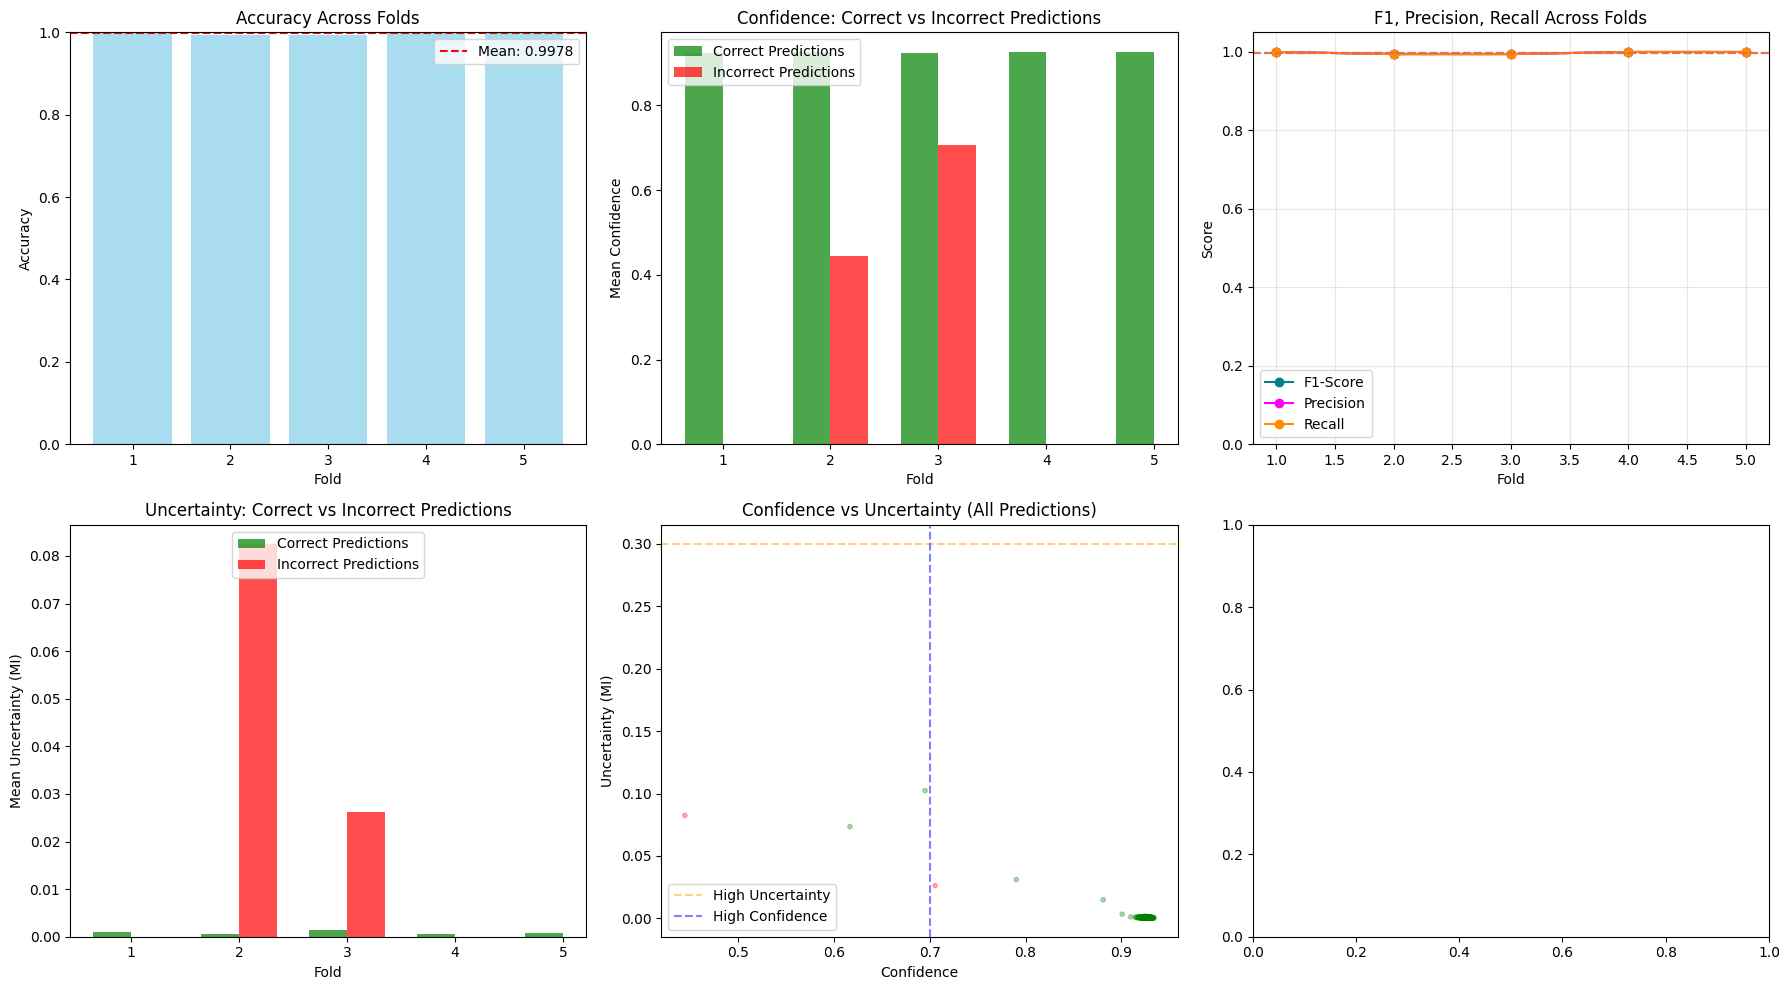


Results saved to 'roberta_tagalog_mcd_foldwise_results.json'
Disk space — Free: 7 GB / Total: 200 GB


In [6]:
import gc

print("\n" + "=" * 80)
print("STARTING FOLD-WISE MONTE CARLO DROPOUT EVALUATION (FIXED MODEL)")
print("=" * 80)

log_disk_space_or_halt(min_free_gb=5)
print("Checkpoint policy: save only the best checkpoint per fold (save_total_limit=1) when fold-level training is enabled.")

classifier = MonteCarloDropoutClassifier(
    model_path=model_path,
    n_iterations=50,
)

print(f"\nModel loaded: {model_path}")
print(f"   Number of classes: {len(classifier.model.config.id2label)}")
print(f"   Classes: {list(classifier.model.config.id2label.values())}")
print("   Monte Carlo iterations: 50")
print(f"   Inference dropout rate: {classifier.inference_dropout_rate}")

cv = MCDCrossValidator(
    classifier=classifier,
    dataset=dataset["test"],
    tokenizer=tokenizer,
    n_splits=5,
    batch_size=16,
)

aggregated_results, fold_results = cv.run_kfold_evaluation()
cv.plot_results()

import json
import numpy as np

def convert_numpy_types(obj):
    if isinstance(obj, (np.floating,)):
        return None if np.isnan(obj) else float(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return [convert_numpy_types(item) for item in obj.tolist()]
    return obj

serializable_aggregated_results = {k: convert_numpy_types(v) for k, v in aggregated_results.items()}

serializable_fold_results = []
for fold in fold_results:
    serializable_fold = {}
    for k, v in fold.items():
        if k not in ["predictions", "labels", "confidences", "uncertainties", "texts"]:
            serializable_fold[k] = convert_numpy_types(v)
    serializable_fold["n_samples"] = len(fold["labels"])
    serializable_fold_results.append(serializable_fold)

with open("roberta_tagalog_mcd_foldwise_results.json", "w") as f:
    json.dump(
        {
            "method": "Monte Carlo Dropout - fold-wise partitioned test evaluation (fixed model)",
            "model": "RoBERTa-Tagalog-base-Symptom2Disease_WITH-DROPOUT-42",
            "n_iterations": 50,
            "inference_dropout_rate": float(classifier.inference_dropout_rate),
            "aggregated": serializable_aggregated_results,
            "folds": serializable_fold_results,
        },
        f,
        indent=2,
    )

print("\nResults saved to 'roberta_tagalog_mcd_foldwise_results.json'")

# Major-section cleanup
if "fold_results" in locals():
    del fold_results
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
log_disk_space_or_halt(min_free_gb=5)

print("=" * 80)

# 5. Baseline RoBERTa Tagalog vs. MCD RoBERTa Tagalog Comparison

## How-To: Interpret Comparison Results

This section compares deterministic baseline inference with MCD inference on the same sample subset.

Focus on these questions:

- Does MCD keep accuracy competitive?
- Are MCD confidence scores more conservative?
- Is uncertainty higher when predictions are incorrect?
- How often do baseline and MCD disagree, and who is right in those cases?

These checks help justify uncertainty-aware inference beyond raw classification performance.

In [7]:
import gc
import numpy as np
from tqdm import tqdm
from transformers import pipeline


def normalize_label_to_id(label, label2id_map, id2label_map=None):
    """Normalize various HF pipeline label formats to integer class ids."""
    if isinstance(label, (int, np.integer)):
        return int(label)

    if isinstance(label, str):
        if label.startswith("LABEL_") and label[6:].isdigit():
            return int(label[6:])
        if label.isdigit():
            return int(label)
        if label in label2id_map:
            return int(label2id_map[label])
        if id2label_map is not None:
            reverse_id_map = {str(v): int(k) for k, v in id2label_map.items()}
            if label in reverse_id_map:
                return reverse_id_map[label]

    raise ValueError(
        f"Unable to normalize label '{label}'. Expected int, LABEL_k, digit string, or known class name."
    )


log_disk_space_or_halt(min_free_gb=5)

print("=" * 80)
print("COMPARATIVE ANALYSIS: MCD vs BASELINE")
print("=" * 80)

mcd_classifier = MonteCarloDropoutClassifier(
    model_path=model_path,
    n_iterations=50,
)

baseline_classifier = pipeline(
    task="text-classification",
    model=model_path,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

comparison_sample_size = min(500, len(dataset["test"]))
inference_batch_size = 16
comparison_samples = dataset["test"].select(range(comparison_sample_size))
comparison_texts = comparison_samples["text"]
true_labels = np.array(comparison_samples["labels"])

mcd_predictions = []
mcd_confidences = []
mcd_uncertainties = []
baseline_predictions = []
baseline_confidences = []

print(f"\nEvaluating {comparison_sample_size} samples with both methods...")

for start in tqdm(range(0, comparison_sample_size, inference_batch_size), desc="Comparing MCD vs Baseline"):
    end = min(start + inference_batch_size, comparison_sample_size)
    batch_texts = comparison_texts[start:end]

    mcd_result = mcd_classifier.predict_batch_with_uncertainty(batch_texts)
    mcd_predictions.extend(mcd_result["predicted_class"].tolist())
    mcd_confidences.extend(mcd_result["confidence"].tolist())
    mcd_uncertainties.extend(mcd_result["mutual_information"].tolist())

    baseline_results = baseline_classifier(
        batch_texts,
        batch_size=inference_batch_size,
        truncation=True,
        max_length=mcd_classifier.max_length,
    )
    baseline_predictions.extend(
        [
            normalize_label_to_id(
                item["label"],
                classifier.model.config.label2id,
                classifier.model.config.id2label,
            )
            for item in baseline_results
        ]
    )
    baseline_confidences.extend([item["score"] for item in baseline_results])

mcd_predictions = np.array(mcd_predictions)
baseline_predictions = np.array(baseline_predictions)
mcd_confidences = np.array(mcd_confidences)
baseline_confidences = np.array(baseline_confidences)
mcd_uncertainties = np.array(mcd_uncertainties)

mcd_accuracy = (mcd_predictions == true_labels).mean()
baseline_accuracy = (baseline_predictions == true_labels).mean()
agreement_rate = (mcd_predictions == baseline_predictions).mean()

mcd_correct = mcd_predictions == true_labels
baseline_correct = baseline_predictions == true_labels

print(f"\nOVERALL PERFORMANCE:")
print(f"   MCD Accuracy:      {mcd_accuracy:.4f} ({int(mcd_accuracy * 100)}%)")
print(f"   Baseline Accuracy: {baseline_accuracy:.4f} ({int(baseline_accuracy * 100)}%)")
print(f"   Agreement Rate:    {agreement_rate:.4f} ({int(agreement_rate * 100)}%)")

print(f"\nCONFIDENCE ANALYSIS:")
print(f"   Mean MCD Confidence:      {mcd_confidences.mean():.4f} +/- {mcd_confidences.std():.4f}")
print(f"   Mean Baseline Confidence: {baseline_confidences.mean():.4f} +/- {baseline_confidences.std():.4f}")
print(f"   Confidence Difference:    {(baseline_confidences.mean() - mcd_confidences.mean()):.4f}")

print(f"\nCALIBRATION ANALYSIS:")
mcd_conf_correct_mean = mcd_confidences[mcd_correct].mean() if mcd_correct.any() else 0.0
mcd_conf_incorrect_mean = mcd_confidences[~mcd_correct].mean() if (~mcd_correct).any() else 0.0
baseline_conf_correct_mean = baseline_confidences[baseline_correct].mean() if baseline_correct.any() else 0.0
baseline_conf_incorrect_mean = baseline_confidences[~baseline_correct].mean() if (~baseline_correct).any() else 0.0

print(f"   MCD Confidence (Correct):        {mcd_conf_correct_mean:.4f}")
print(f"   MCD Confidence (Incorrect):      {mcd_conf_incorrect_mean:.4f}")
print(f"   Baseline Confidence (Correct):   {baseline_conf_correct_mean:.4f}")
print(f"   Baseline Confidence (Incorrect): {baseline_conf_incorrect_mean:.4f}")

print(f"\nUNCERTAINTY INSIGHTS:")
mcd_unc_correct_mean = mcd_uncertainties[mcd_correct].mean() if mcd_correct.any() else 0.0
mcd_unc_incorrect_mean = mcd_uncertainties[~mcd_correct].mean() if (~mcd_correct).any() else 0.0

print(f"   Mean MCD Uncertainty (MI):       {mcd_uncertainties.mean():.4f} +/- {mcd_uncertainties.std():.4f}")
print(f"   MCD Uncertainty (Correct):       {mcd_unc_correct_mean:.4f}")
print(f"   MCD Uncertainty (Incorrect):     {mcd_unc_incorrect_mean:.4f}")

uncertainty_separation = mcd_unc_incorrect_mean - mcd_unc_correct_mean
print(f"   Separation:                      {uncertainty_separation:.4f}")

print(f"\nDISAGREEMENT ANALYSIS:")
disagreements = mcd_predictions != baseline_predictions
num_disagreements = disagreements.sum()
print(f"   Total Disagreements: {num_disagreements} ({num_disagreements / comparison_sample_size * 100:.1f}%)")

if num_disagreements > 0:
    mcd_right_baseline_wrong = (mcd_correct & ~baseline_correct).sum()
    baseline_right_mcd_wrong = (~mcd_correct & baseline_correct).sum()
    both_wrong = (~mcd_correct & ~baseline_correct & disagreements).sum()

    print(f"   MCD Correct, Baseline Wrong:  {mcd_right_baseline_wrong}")
    print(f"   Baseline Correct, MCD Wrong:  {baseline_right_mcd_wrong}")
    print(f"   Both Wrong (disagreements):   {both_wrong}")

    avg_uncertainty_disagreements = mcd_uncertainties[disagreements].mean()
    print(f"   Avg MCD Uncertainty (disagreements): {avg_uncertainty_disagreements:.4f}")

print(f"\nKEY INSIGHTS:")
if mcd_confidences.mean() < baseline_confidences.mean():
    print("   - MCD provides more conservative confidence estimates (often better calibration).")
if uncertainty_separation > 0.05:
    print("   - MCD uncertainty separates correct vs incorrect predictions.")
if mcd_accuracy >= baseline_accuracy:
    print("   - MCD maintains or improves accuracy while adding uncertainty estimates.")

# Major-section cleanup (keep arrays needed by following plotting/confusion cells)
del baseline_classifier
del mcd_classifier
del comparison_samples
del comparison_texts
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
log_disk_space_or_halt(min_free_gb=5)

print("=" * 80)

Disk space — Free: 7 GB / Total: 200 GB
COMPARATIVE ANALYSIS: MCD vs BASELINE


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1334.66it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              



Evaluating 500 samples with both methods...


Comparing MCD vs Baseline: 100%|██████████| 32/32 [01:14<00:00,  2.33s/it]



OVERALL PERFORMANCE:
   MCD Accuracy:      0.9980 (99%)
   Baseline Accuracy: 0.9980 (99%)
   Agreement Rate:    1.0000 (100%)

CONFIDENCE ANALYSIS:
   Mean MCD Confidence:      0.9233 +/- 0.0290
   Mean Baseline Confidence: 0.9329 +/- 0.0265
   Confidence Difference:    0.0096

CALIBRATION ANALYSIS:
   MCD Confidence (Correct):        0.9237
   MCD Confidence (Incorrect):      0.7099
   Baseline Confidence (Correct):   0.9333
   Baseline Confidence (Incorrect): 0.7365

UNCERTAINTY INSIGHTS:
   Mean MCD Uncertainty (MI):       0.0011 +/- 0.0061
   MCD Uncertainty (Correct):       0.0011
   MCD Uncertainty (Incorrect):     0.0168
   Separation:                      0.0158

DISAGREEMENT ANALYSIS:
   Total Disagreements: 0 (0.0%)

KEY INSIGHTS:
   - MCD provides more conservative confidence estimates (often better calibration).
   - MCD maintains or improves accuracy while adding uncertainty estimates.
Disk space — Free: 7 GB / Total: 200 GB


/tmp/ipykernel_55959/1920444338.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_comparison, x='Method', y='Confidence', ax=axes[1, 2], palette=['lightblue', 'lightcoral', 'lightgreen', 'salmon'])


✅ Visualization saved to 'mcd_vs_baseline_comparison.png'


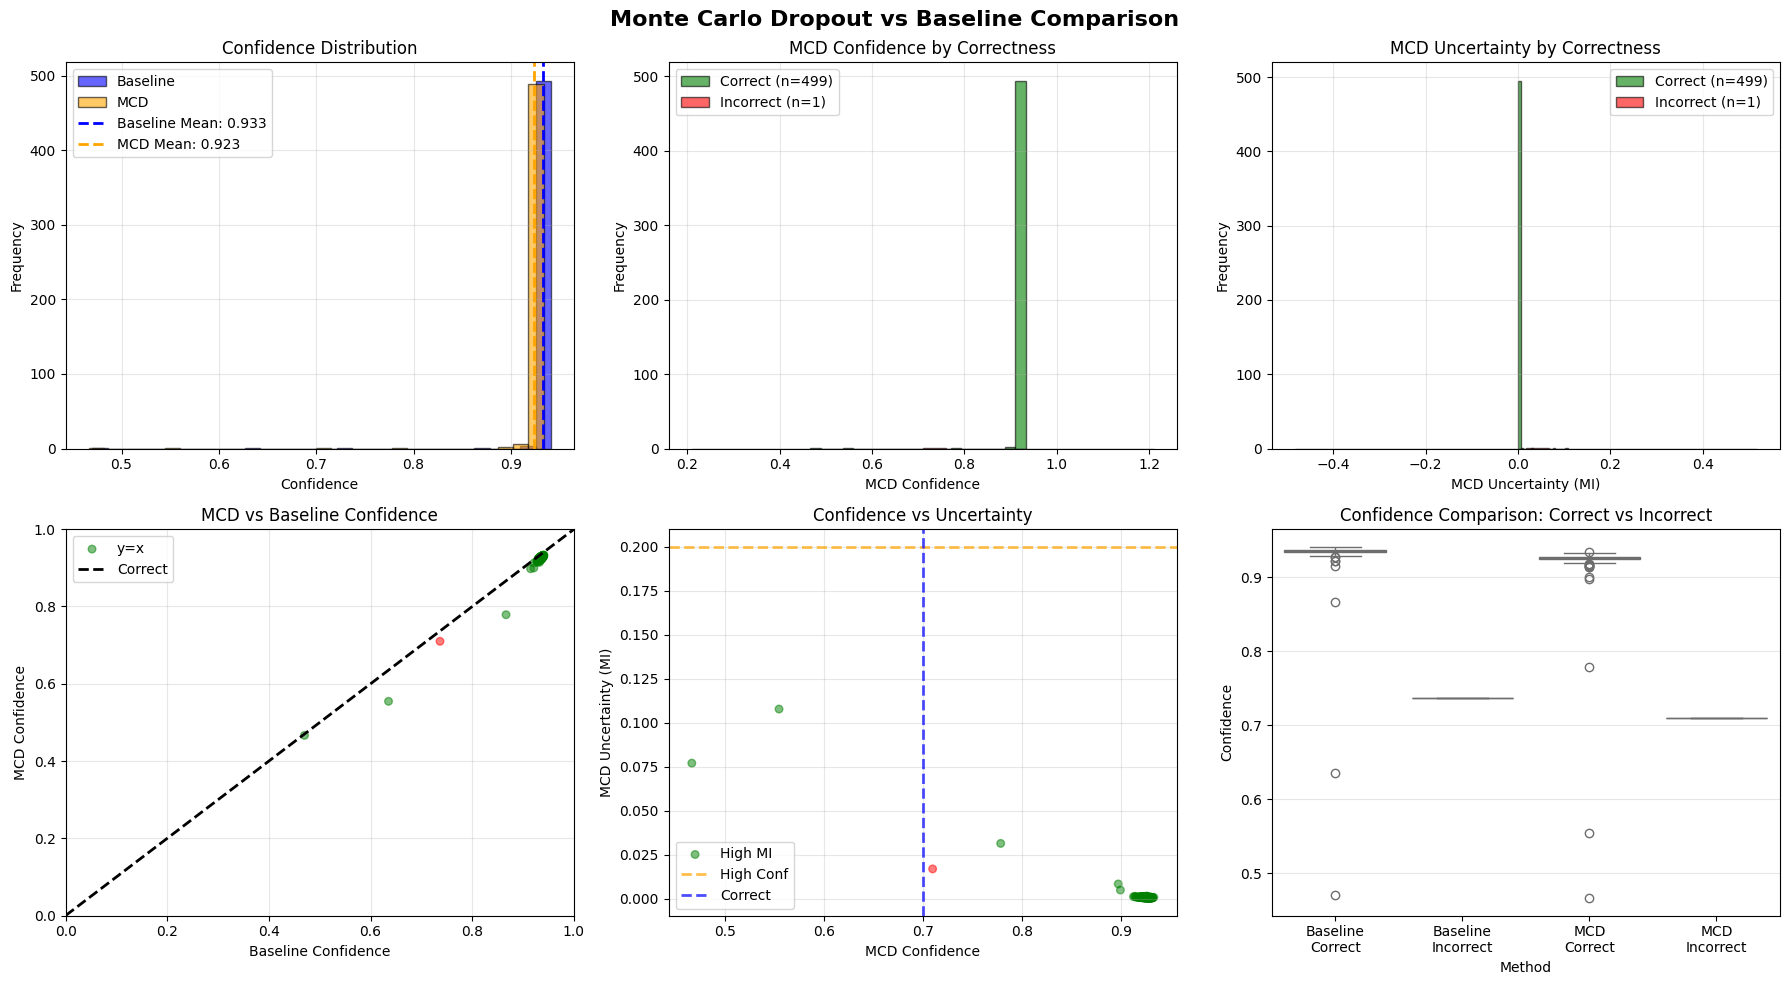

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Monte Carlo Dropout vs Baseline Comparison', fontsize=16, fontweight='bold')

# 1. Confidence Distribution Comparison
axes[0, 0].hist(baseline_confidences, bins=30, alpha=0.6, label='Baseline', color='blue', edgecolor='black')
axes[0, 0].hist(mcd_confidences, bins=30, alpha=0.6, label='MCD', color='orange', edgecolor='black')
axes[0, 0].axvline(baseline_confidences.mean(), color='blue', linestyle='--', linewidth=2, label=f'Baseline Mean: {baseline_confidences.mean():.3f}')
axes[0, 0].axvline(mcd_confidences.mean(), color='orange', linestyle='--', linewidth=2, label=f'MCD Mean: {mcd_confidences.mean():.3f}')
axes[0, 0].set_xlabel('Confidence')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Confidence Distribution')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Confidence: Correct vs Incorrect (MCD)
correct_mcd = mcd_confidences[mcd_correct]
incorrect_mcd = mcd_confidences[~mcd_correct]
axes[0, 1].hist(correct_mcd, bins=20, alpha=0.6, label=f'Correct (n={len(correct_mcd)})', color='green', edgecolor='black')
axes[0, 1].hist(incorrect_mcd, bins=20, alpha=0.6, label=f'Incorrect (n={len(incorrect_mcd)})', color='red', edgecolor='black')
axes[0, 1].set_xlabel('MCD Confidence')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('MCD Confidence by Correctness')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Uncertainty by Correctness (MCD)
correct_unc = mcd_uncertainties[mcd_correct]
incorrect_unc = mcd_uncertainties[~mcd_correct]
axes[0, 2].hist(correct_unc, bins=20, alpha=0.6, label=f'Correct (n={len(correct_unc)})', color='green', edgecolor='black')
axes[0, 2].hist(incorrect_unc, bins=20, alpha=0.6, label=f'Incorrect (n={len(incorrect_unc)})', color='red', edgecolor='black')
axes[0, 2].set_xlabel('MCD Uncertainty (MI)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('MCD Uncertainty by Correctness')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. MCD Confidence vs Baseline Confidence
axes[1, 0].scatter(baseline_confidences, mcd_confidences, alpha=0.5, c=['green' if c else 'red' for c in mcd_correct], s=30)
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='y=x (Perfect Agreement)')
axes[1, 0].set_xlabel('Baseline Confidence')
axes[1, 0].set_ylabel('MCD Confidence')
axes[1, 0].set_title('MCD vs Baseline Confidence')
axes[1, 0].legend(['y=x', 'Correct', 'Incorrect'])
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([0, 1])

# 5. Confidence vs Uncertainty Scatter
colors = ['green' if c else 'red' for c in mcd_correct]
axes[1, 1].scatter(mcd_confidences, mcd_uncertainties, c=colors, alpha=0.5, s=30)
axes[1, 1].axhline(y=0.2, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='High Uncertainty Threshold')
axes[1, 1].axvline(x=0.7, color='blue', linestyle='--', alpha=0.7, linewidth=2, label='High Confidence Threshold')
axes[1, 1].set_xlabel('MCD Confidence')
axes[1, 1].set_ylabel('MCD Uncertainty (MI)')
axes[1, 1].set_title('Confidence vs Uncertainty')
axes[1, 1].legend(['High MI', 'High Conf', 'Correct', 'Incorrect'])
axes[1, 1].grid(alpha=0.3)

# 6. Box plot comparison
comparison_data = []
comparison_labels = []

comparison_data.extend(baseline_confidences[baseline_correct])
comparison_labels.extend(['Baseline\nCorrect'] * len(baseline_confidences[baseline_correct]))

comparison_data.extend(baseline_confidences[~baseline_correct])
comparison_labels.extend(['Baseline\nIncorrect'] * len(baseline_confidences[~baseline_correct]))

comparison_data.extend(mcd_confidences[mcd_correct])
comparison_labels.extend(['MCD\nCorrect'] * len(mcd_confidences[mcd_correct]))

comparison_data.extend(mcd_confidences[~mcd_correct])
comparison_labels.extend(['MCD\nIncorrect'] * len(mcd_confidences[~mcd_correct]))

import pandas as pd
df_comparison = pd.DataFrame({'Confidence': comparison_data, 'Method': comparison_labels})
sns.boxplot(data=df_comparison, x='Method', y='Confidence', ax=axes[1, 2], palette=['lightblue', 'lightcoral', 'lightgreen', 'salmon'])
axes[1, 2].set_title('Confidence Comparison: Correct vs Incorrect')
axes[1, 2].set_ylabel('Confidence')
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('mcd_vs_baseline_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved to 'mcd_vs_baseline_comparison.png'")
plt.show()

# 6. Inference Dropout Sensitivity Analysis

## Explanation: Choosing an Inference Dropout Rate

This experiment sweeps multiple inference-time dropout rates while keeping model weights fixed.

## What to Look For

- Stable or improved accuracy.
- Better separation between uncertainty for correct vs incorrect predictions.
- Better separation between confidence for correct vs incorrect predictions.
- Acceptable prediction stability (lower variance in max probability across MC passes).

Use the composite score as a practical ranking signal, then validate the selected rate against your risk tolerance and deployment constraints.

In [9]:
import gc

log_disk_space_or_halt(min_free_gb=5)

print("=" * 80)
print("INFERENCE DROPOUT RATE SENSITIVITY ANALYSIS")
print("=" * 80)

test_subset_size = min(500, len(dataset["test"]))
test_subset = dataset["test"].select(range(test_subset_size))
test_texts = test_subset["text"]
true_labels = np.array(test_subset["labels"])

inference_dropout_rates = [0.0, 0.025, 0.05, 0.075, 0.1, 0.15]
dropout_rate_results = []
inference_batch_size = 16

# Reuse one model instance and only change inference dropout probability.
classifier_temp = MonteCarloDropoutClassifier(
    model_path=model_path,
    n_iterations=50,
    inference_dropout_rate=inference_dropout_rates[0],
)

for rate in inference_dropout_rates:
    print(f"\n{'=' * 80}")
    print(f"Testing Inference Dropout Rate: {rate}")
    print(f"{'=' * 80}")

    classifier_temp.set_inference_dropout_rate(rate)

    predictions = []
    confidences = []
    uncertainties = []
    entropies = []
    prediction_stds = []

    print(f"Evaluating {test_subset_size} samples with dropout rate {rate}...")

    for start in tqdm(range(0, test_subset_size, inference_batch_size), desc=f"Rate {rate}"):
        end = min(start + inference_batch_size, test_subset_size)
        batch_texts = test_texts[start:end]

        result = classifier_temp.predict_batch_with_uncertainty(
            batch_texts,
            return_all_predictions=True,
        )

        predictions.extend(result["predicted_class"].tolist())
        confidences.extend(result["confidence"].tolist())
        uncertainties.extend(result["mutual_information"].tolist())
        entropies.extend(result["predictive_entropy"].tolist())

        all_preds_array = result["all_predictions"]  # (n_iterations, batch_size, n_classes)
        max_probs_per_iter = all_preds_array.max(axis=-1)  # (n_iterations, batch_size)
        pred_std_batch = max_probs_per_iter.std(axis=0)
        prediction_stds.extend(pred_std_batch.tolist())

    predictions = np.array(predictions)
    confidences = np.array(confidences)
    uncertainties = np.array(uncertainties)
    entropies = np.array(entropies)
    prediction_stds = np.array(prediction_stds)

    correct = predictions == true_labels
    accuracy = correct.mean()

    conf_correct = confidences[correct].mean() if correct.any() else 0.0
    conf_incorrect = confidences[~correct].mean() if (~correct).any() else 0.0
    conf_separation = conf_correct - conf_incorrect

    unc_correct = uncertainties[correct].mean() if correct.any() else 0.0
    unc_incorrect = uncertainties[~correct].mean() if (~correct).any() else 0.0
    unc_separation = unc_incorrect - unc_correct

    mean_pred_std = prediction_stds.mean()

    result_dict = {
        "dropout_rate": rate,
        "accuracy": accuracy,
        "mean_confidence": confidences.mean(),
        "confidence_correct": conf_correct,
        "confidence_incorrect": conf_incorrect,
        "confidence_separation": conf_separation,
        "mean_uncertainty": uncertainties.mean(),
        "uncertainty_correct": unc_correct,
        "uncertainty_incorrect": unc_incorrect,
        "uncertainty_separation": unc_separation,
        "mean_entropy": entropies.mean(),
        "mean_prediction_std": mean_pred_std,
        "n_correct": int(correct.sum()),
        "n_incorrect": int((~correct).sum()),
    }

    dropout_rate_results.append(result_dict)

    print(f"\nRESULTS for dropout rate {rate}:")
    print(f"   Accuracy:                    {accuracy:.4f} ({int(accuracy * 100)}%)")
    print(f"   Mean Confidence:             {confidences.mean():.4f}")
    print(f"   Confidence (Correct):        {conf_correct:.4f}")
    print(f"   Confidence (Incorrect):      {conf_incorrect:.4f}")
    print(f"   Confidence Separation:       {conf_separation:.4f}")
    print(f"   Mean Uncertainty (MI):       {uncertainties.mean():.4f}")
    print(f"   Uncertainty (Correct):       {unc_correct:.4f}")
    print(f"   Uncertainty (Incorrect):     {unc_incorrect:.4f}")
    print(f"   Uncertainty Separation:      {unc_separation:.4f}")
    print(f"   Mean Prediction Std:         {mean_pred_std:.4f}")

print(f"\n{'=' * 80}")
print("DROPOUT RATE SENSITIVITY ANALYSIS COMPLETE")
print("=" * 80)

import pandas as pd

df_dropout_comparison = pd.DataFrame(dropout_rate_results)
print("\nSUMMARY TABLE:")
print(df_dropout_comparison.to_string(index=False))

import json

def convert_for_json(obj):
    if isinstance(obj, (np.float32, np.float64)):
        return None if np.isnan(obj) else float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    return obj

serializable_results = [
    {k: convert_for_json(v) for k, v in result.items()}
    for result in dropout_rate_results
]

with open("dropout_rate_sensitivity_analysis.json", "w") as f:
    json.dump(
        {
            "experiment": "Inference Dropout Rate Sensitivity Analysis",
            "model": model_path,
            "n_iterations": 50,
            "test_samples": test_subset_size,
            "results": serializable_results,
        },
        f,
        indent=2,
    )

print("\nResults saved to 'dropout_rate_sensitivity_analysis.json'")

# Major-section cleanup (keep df_dropout_comparison for plotting cell)
del classifier_temp
del test_subset
del test_texts
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
log_disk_space_or_halt(min_free_gb=5)

Disk space — Free: 7 GB / Total: 200 GB
INFERENCE DROPOUT RATE SENSITIVITY ANALYSIS


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1372.14it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              



Testing Inference Dropout Rate: 0.0
Evaluating 500 samples with dropout rate 0.0...


Rate 0.0: 100%|██████████| 32/32 [01:11<00:00,  2.24s/it]



RESULTS for dropout rate 0.0:
   Accuracy:                    0.9980 (99%)
   Mean Confidence:             0.9329
   Confidence (Correct):        0.9333
   Confidence (Incorrect):      0.7365
   Confidence Separation:       0.1968
   Mean Uncertainty (MI):       0.0000
   Uncertainty (Correct):       0.0000
   Uncertainty (Incorrect):     0.0000
   Uncertainty Separation:      0.0000
   Mean Prediction Std:         0.0000

Testing Inference Dropout Rate: 0.025
Evaluating 500 samples with dropout rate 0.025...


...

Rate 0.1: 100%|██████████| 32/32 [01:12<00:00,  2.25s/it]



RESULTS for dropout rate 0.1:
   Accuracy:                    0.9960 (99%)
   Mean Confidence:             0.9122
   Confidence (Correct):        0.9135
   Confidence (Incorrect):      0.5676
   Confidence Separation:       0.3460
   Mean Uncertainty (MI):       0.0023
   Uncertainty (Correct):       0.0020
   Uncertainty (Incorrect):     0.0709
   Uncertainty Separation:      0.0689
   Mean Prediction Std:         0.0127

Testing Inference Dropout Rate: 0.15
Evaluating 500 samples with dropout rate 0.15...


Rate 0.15: 100%|██████████| 32/32 [01:13<00:00,  2.29s/it]



RESULTS for dropout rate 0.15:
   Accuracy:                    0.9980 (99%)
   Mean Confidence:             0.8985
   Confidence (Correct):        0.8990
   Confidence (Incorrect):      0.6770
   Confidence Separation:       0.2220
   Mean Uncertainty (MI):       0.0038
   Uncertainty (Correct):       0.0037
   Uncertainty (Incorrect):     0.0401
   Uncertainty Separation:      0.0364
   Mean Prediction Std:         0.0180

DROPOUT RATE SENSITIVITY ANALYSIS COMPLETE

SUMMARY TABLE:
 dropout_rate  accuracy  mean_confidence  confidence_correct  confidence_incorrect  confidence_separation  mean_uncertainty  uncertainty_correct  uncertainty_incorrect  uncertainty_separation  mean_entropy  mean_prediction_std  n_correct  n_incorrect
        0.000     0.998         0.932887            0.933281              0.736520               0.196760      8.821487e-09         7.644684e-09           5.960464e-07            5.884018e-07      0.349552         3.054738e-07        499            1
        0.

7

✅ Visualization saved to 'dropout_rate_sensitivity_analysis.png'


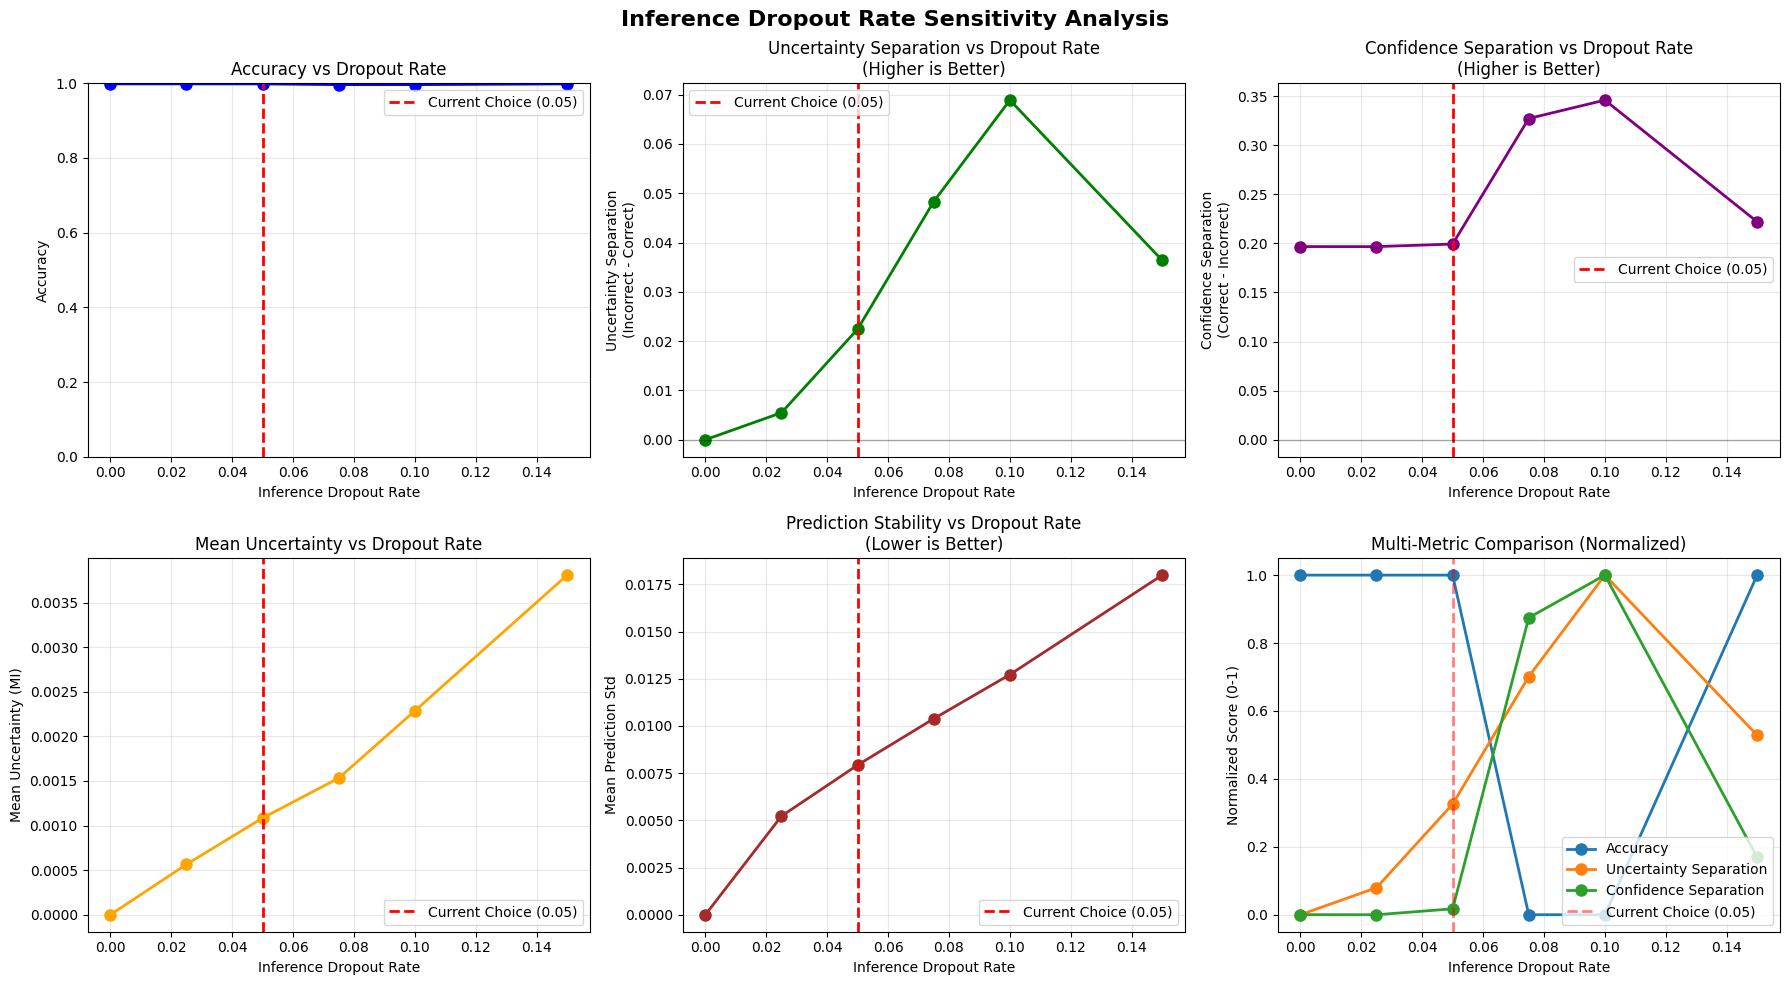


🎯 RECOMMENDATION

📊 Based on composite scoring (accuracy + unc_sep + conf_sep - pred_std):
   Optimal Dropout Rate: 0.1
   Current Choice: 0.05

   ⚠️  Analysis suggests 0.1 may be better than 0.05
   Consider reviewing trade-offs

💡 Key Findings:
   Dropout rate 0.05 achieves:
      Accuracy: 0.9980
      Uncertainty Separation: 0.0224
      Confidence Separation: 0.1993
      Prediction Stability (std): 0.0079


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Inference Dropout Rate Sensitivity Analysis', fontsize=16, fontweight='bold')

dropout_rates = df_dropout_comparison['dropout_rate'].values

# 1. Accuracy vs Dropout Rate
axes[0, 0].plot(dropout_rates, df_dropout_comparison['accuracy'], 'o-', linewidth=2, markersize=8, color='blue')
axes[0, 0].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Current Choice (0.05)')
axes[0, 0].set_xlabel('Inference Dropout Rate')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy vs Dropout Rate')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# 2. Uncertainty Separation vs Dropout Rate
axes[0, 1].plot(dropout_rates, df_dropout_comparison['uncertainty_separation'], 'o-', linewidth=2, markersize=8, color='green')
axes[0, 1].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Current Choice (0.05)')
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[0, 1].set_xlabel('Inference Dropout Rate')
axes[0, 1].set_ylabel('Uncertainty Separation\n(Incorrect - Correct)')
axes[0, 1].set_title('Uncertainty Separation vs Dropout Rate\n(Higher is Better)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Confidence Separation vs Dropout Rate
axes[0, 2].plot(dropout_rates, df_dropout_comparison['confidence_separation'], 'o-', linewidth=2, markersize=8, color='purple')
axes[0, 2].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Current Choice (0.05)')
axes[0, 2].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[0, 2].set_xlabel('Inference Dropout Rate')
axes[0, 2].set_ylabel('Confidence Separation\n(Correct - Incorrect)')
axes[0, 2].set_title('Confidence Separation vs Dropout Rate\n(Higher is Better)')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. Mean Uncertainty vs Dropout Rate
axes[1, 0].plot(dropout_rates, df_dropout_comparison['mean_uncertainty'], 'o-', linewidth=2, markersize=8, color='orange')
axes[1, 0].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Current Choice (0.05)')
axes[1, 0].set_xlabel('Inference Dropout Rate')
axes[1, 0].set_ylabel('Mean Uncertainty (MI)')
axes[1, 0].set_title('Mean Uncertainty vs Dropout Rate')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 5. Prediction Stability (Std) vs Dropout Rate
axes[1, 1].plot(dropout_rates, df_dropout_comparison['mean_prediction_std'], 'o-', linewidth=2, markersize=8, color='brown')
axes[1, 1].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Current Choice (0.05)')
axes[1, 1].set_xlabel('Inference Dropout Rate')
axes[1, 1].set_ylabel('Mean Prediction Std')
axes[1, 1].set_title('Prediction Stability vs Dropout Rate\n(Lower is Better)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Multi-metric comparison (normalized)
# Normalize metrics to 0-1 scale for comparison
from sklearn.preprocessing import MinMaxScaler

metrics_to_plot = ['accuracy', 'uncertainty_separation', 'confidence_separation']
scaler = MinMaxScaler()

normalized_data = df_dropout_comparison[metrics_to_plot].copy()
normalized_data = pd.DataFrame(
    scaler.fit_transform(normalized_data),
    columns=metrics_to_plot
)

for metric in metrics_to_plot:
    axes[1, 2].plot(dropout_rates, normalized_data[metric], 'o-', linewidth=2, markersize=8, label=metric.replace('_', ' ').title())

axes[1, 2].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Current Choice (0.05)', alpha=0.5)
axes[1, 2].set_xlabel('Inference Dropout Rate')
axes[1, 2].set_ylabel('Normalized Score (0-1)')
axes[1, 2].set_title('Multi-Metric Comparison (Normalized)')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dropout_rate_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Visualization saved to 'dropout_rate_sensitivity_analysis.png'")
plt.show()

# Print recommendation
print("\n" + "="*80)
print("🎯 RECOMMENDATION")
print("="*80)

# Find optimal dropout rate based on composite score
df_dropout_comparison['composite_score'] = (
    df_dropout_comparison['accuracy'] +
    df_dropout_comparison['uncertainty_separation'] +
    df_dropout_comparison['confidence_separation'] -
    df_dropout_comparison['mean_prediction_std']
)

optimal_idx = df_dropout_comparison['composite_score'].idxmax()
optimal_rate = df_dropout_comparison.loc[optimal_idx, 'dropout_rate']

print(f"\n📊 Based on composite scoring (accuracy + unc_sep + conf_sep - pred_std):")
print(f"   Optimal Dropout Rate: {optimal_rate}")
print(f"   Current Choice: 0.05")

if optimal_rate == 0.05:
    print(f"\n   ✅ CONFIRMED: 0.05 is the optimal choice!")
else:
    print(f"\n   ⚠️  Analysis suggests {optimal_rate} may be better than 0.05")
    print(f"   Consider reviewing trade-offs")

print("\n💡 Key Findings:")
rate_05_data = df_dropout_comparison[df_dropout_comparison['dropout_rate'] == 0.05].iloc[0]
print(f"   Dropout rate 0.05 achieves:")
print(f"      Accuracy: {rate_05_data['accuracy']:.4f}")
print(f"      Uncertainty Separation: {rate_05_data['uncertainty_separation']:.4f}")
print(f"      Confidence Separation: {rate_05_data['confidence_separation']:.4f}")
print(f"      Prediction Stability (std): {rate_05_data['mean_prediction_std']:.4f}")

print("="*80)

# 7. Monte Carlo Iterations Sensitivity Analysis

## Theoretical Basis: Why the Number of MC Iterations Matters

Monte Carlo Dropout (MCD) approximates Bayesian inference by performing multiple stochastic forward passes through the network with dropout active at inference time. Each pass produces a different set of predictions because different neurons are randomly deactivated. The final prediction is the average of these individual predictions, and the variance across passes quantifies the model's uncertainty.

Mathematically, MCD approximates the posterior predictive distribution:

$$p(y|x, D) \approx \frac{1}{T} \sum_{t=1}^{T} p(y|x, \hat{W}_t)$$

where $T$ is the number of Monte Carlo iterations and $\hat{W}_t$ represents the randomly sampled network weights at iteration $t$ (via dropout masks). This is a Monte Carlo integration of the intractable Bayesian integral over the weight posterior.

## The Tradeoff: Uncertainty Quality vs. Computational Cost

The number of iterations $T$ directly controls the precision of this approximation:

- **Too few iterations** ($T < 10$): The Monte Carlo estimate is noisy. Entropy and mutual information values fluctuate significantly between runs, making uncertainty estimates unreliable for downstream decision-making (e.g., flagging high-uncertainty predictions for clinician review).

- **Enough iterations** ($T \approx 30$--$50$): The law of large numbers ensures convergence. Uncertainty metrics stabilize, and the mean prediction closely approximates the true Bayesian posterior mean. This is the "sweet spot" for most practical applications.

- **Excessive iterations** ($T > 75$): Diminishing returns. The uncertainty estimates improve marginally (often within noise), but computational cost scales linearly. For a real-time diagnostic system, this latency may be unacceptable.

## What This Experiment Tests

This section sweeps iteration counts from 5 to 100 while keeping the inference dropout rate fixed at the optimal value (0.05, determined in Section 6). For each iteration count, we measure:

- **Accuracy**: Does prediction quality change with more iterations? (Expected: flat, since the mean prediction converges quickly.)
- **Mean confidence and entropy**: How do aggregate confidence scores evolve?
- **Uncertainty separation**: Does mutual information better distinguish correct from incorrect predictions at higher $T$?
- **Prediction stability** (std of max probabilities across MC passes): A direct measure of per-sample uncertainty variance.
- **Wall-clock time**: The real-world cost of each iteration count.

## How to Interpret the Results

Look for the "elbow" in the convergence plots — the point where additional iterations yield negligible improvements in uncertainty quality relative to the added compute cost. This is the recommended iteration count for deployment.

The composite score balances accuracy, uncertainty separation, and efficiency to produce a single ranking metric. However, always validate the recommendation against your specific latency requirements and risk tolerance.


Disk space — Free: 7 GB / Total: 200 GB
MONTE CARLO ITERATIONS SENSITIVITY ANALYSIS


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1361.19it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              



Testing Monte Carlo Iterations: 5
Evaluating 900 samples with 5 iterations...


Iterations 5: 100%|██████████| 57/57 [00:13<00:00,  4.30it/s]



RESULTS for 5 iterations:
   Accuracy:                    0.9989 (99%)
   Mean Confidence:             0.9248
   Confidence (Correct):        0.9250
   Confidence (Incorrect):      0.7005
   Confidence Separation:       0.2245
   Mean Uncertainty (MI):       0.0007
   Uncertainty (Correct):       0.0007
   Uncertainty (Incorrect):     0.0312
   Uncertainty Separation:      0.0305
   Mean Prediction Std:         0.0066
   Elapsed Time:                13.3s (14.7ms/sample)
Disk space — Free: 7 GB / Total: 200 GB

Testing Monte Carlo Iterations: 10
Evaluating 900 samples with 10 iterations...


...


RESULTS for 50 iterations:
   Accuracy:                    0.9989 (99%)
   Mean Confidence:             0.9243
   Confidence (Correct):        0.9246
   Confidence (Incorrect):      0.6923
   Confidence Separation:       0.2322
   Mean Uncertainty (MI):       0.0010
   Uncertainty (Correct):       0.0009
   Uncertainty (Incorrect):     0.0212
   Uncertainty Separation:      0.0203
   Mean Prediction Std:         0.0076
   Elapsed Time:                133.3s (148.1ms/sample)
Disk space — Free: 7 GB / Total: 200 GB

Testing Monte Carlo Iterations: 75
Evaluating 900 samples with 75 iterations...


Iterations 75: 100%|██████████| 57/57 [03:18<00:00,  3.49s/it]



RESULTS for 75 iterations:
   Accuracy:                    0.9978 (99%)
   Mean Confidence:             0.9243
   Confidence (Correct):        0.9251
   Confidence (Incorrect):      0.5817
   Confidence Separation:       0.3433
   Mean Uncertainty (MI):       0.0009
   Uncertainty (Correct):       0.0008
   Uncertainty (Incorrect):     0.0499
   Uncertainty Separation:      0.0491
   Mean Prediction Std:         0.0077
   Elapsed Time:                198.9s (221.0ms/sample)
Disk space — Free: 7 GB / Total: 200 GB

Testing Monte Carlo Iterations: 100
Evaluating 900 samples with 100 iterations...


Iterations 100: 100%|██████████| 57/57 [04:27<00:00,  4.69s/it]



RESULTS for 100 iterations:
   Accuracy:                    0.9989 (99%)
   Mean Confidence:             0.9243
   Confidence (Correct):        0.9245
   Confidence (Incorrect):      0.7058
   Confidence Separation:       0.2188
   Mean Uncertainty (MI):       0.0010
   Uncertainty (Correct):       0.0010
   Uncertainty (Incorrect):     0.0225
   Uncertainty Separation:      0.0216
   Mean Prediction Std:         0.0077
   Elapsed Time:                267.3s (297.0ms/sample)
Disk space — Free: 7 GB / Total: 200 GB

MC ITERATIONS SENSITIVITY ANALYSIS COMPLETE

SUMMARY TABLE:
 n_iterations  accuracy  mean_confidence  confidence_correct  confidence_incorrect  confidence_separation  mean_uncertainty  uncertainty_correct  uncertainty_incorrect  uncertainty_separation  mean_entropy  mean_prediction_std  elapsed_seconds  time_per_sample_ms  n_correct  n_incorrect
            5  0.998889         0.924780            0.925030              0.700503               0.224526          0.000694       

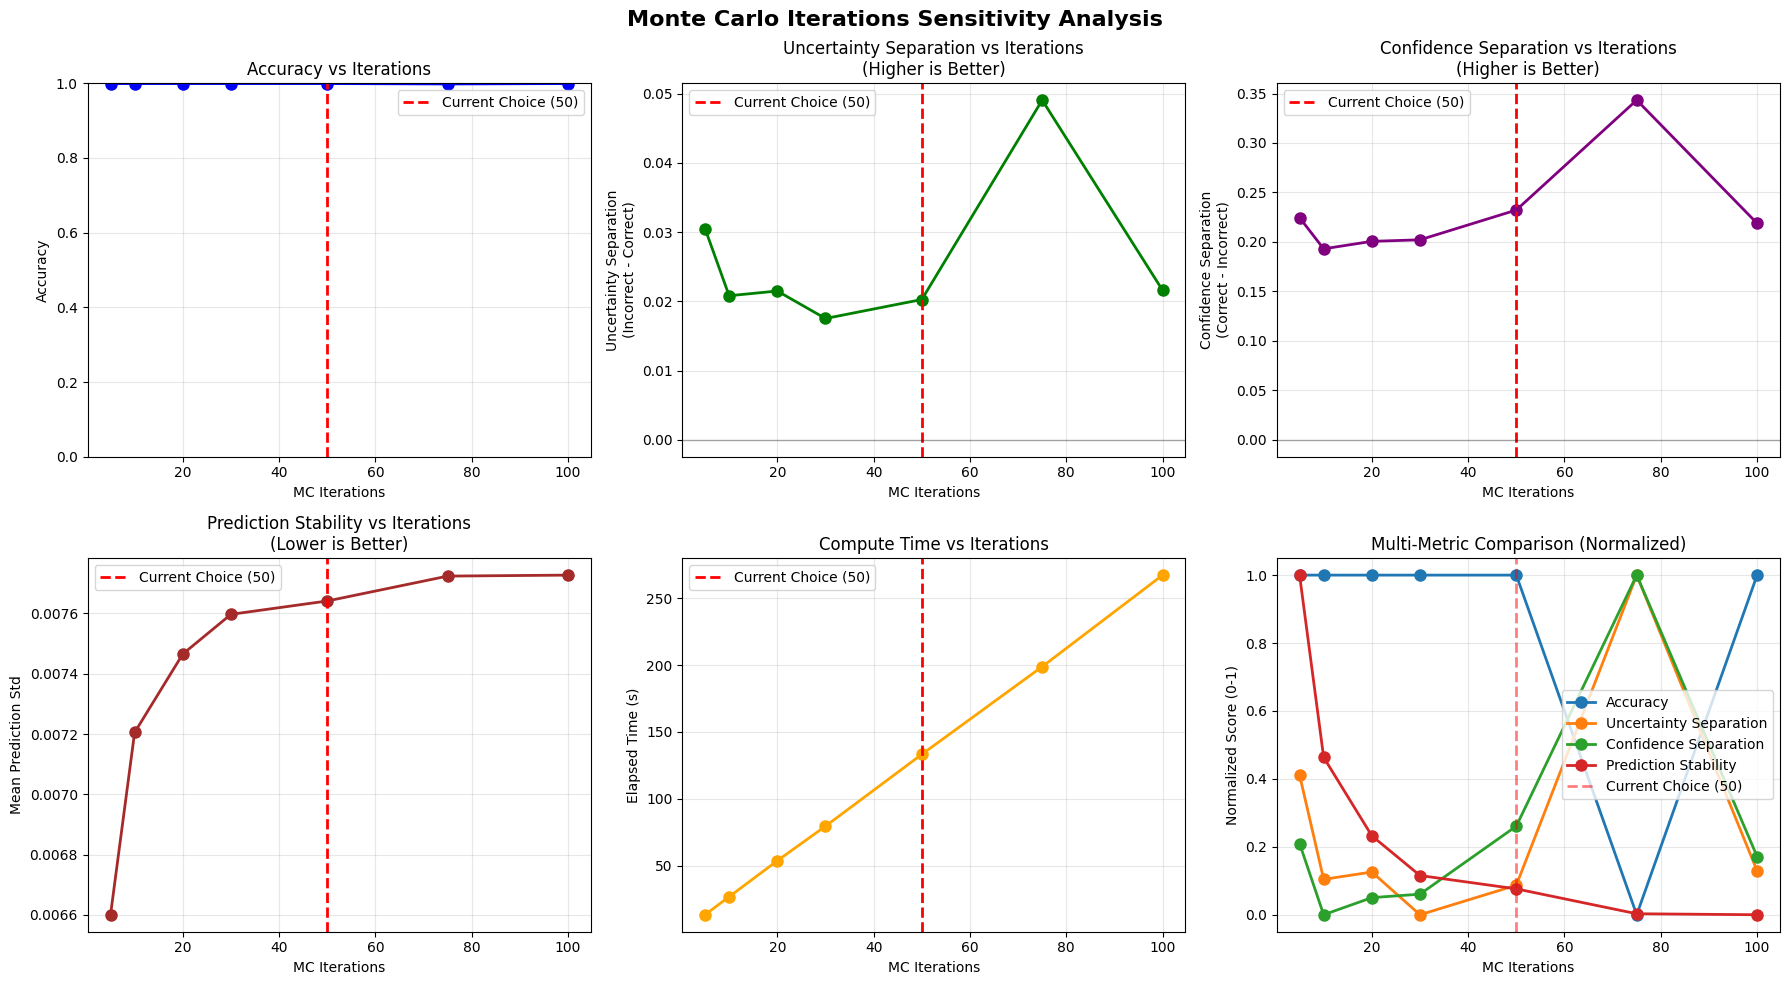


RECOMMENDATION

Based on composite scoring (accuracy + unc_sep + conf_sep - pred_std):
   Optimal Iterations: 75
   Current Choice: 50

   Analysis suggests 75 iterations may be better than 50
   Consider reviewing trade-offs

Key Findings:
   50 iterations achieves:
      Accuracy: 0.9989
      Uncertainty Separation: 0.0203
      Confidence Separation: 0.2322
      Prediction Stability (std): 0.0076
      Elapsed Time: 133.3s


In [11]:
import gc
import time
import numpy as np
from tqdm import tqdm

log_disk_space_or_halt(min_free_gb=5)

print("=" * 80)
print("MONTE CARLO ITERATIONS SENSITIVITY ANALYSIS")
print("=" * 80)

# Fixed parameters
fixed_dropout_rate = 0.05
iteration_counts = [5, 10, 20, 30, 50, 75, 100]
inference_batch_size = 16

# Use full test set
test_size = len(dataset["test"])
test_texts = dataset["test"]["text"]
true_labels = np.array(dataset["test"]["labels"])

iteration_results = []

# Create classifier once and reuse (only change n_iterations)
base_classifier = MonteCarloDropoutClassifier(
    model_path=model_path,
    n_iterations=iteration_counts[0],
    inference_dropout_rate=fixed_dropout_rate,
)

for n_iter in iteration_counts:
    print(f"\n{'=' * 80}")
    print(f"Testing Monte Carlo Iterations: {n_iter}")
    print(f"{'=' * 80}")

    base_classifier.n_iterations = n_iter
    base_classifier._dropout_is_configured = False

    predictions = []
    confidences = []
    uncertainties = []
    entropies = []
    prediction_stds = []

    print(f"Evaluating {test_size} samples with {n_iter} iterations...")

    start_time = time.perf_counter()

    for start in tqdm(range(0, test_size, inference_batch_size), desc=f"Iterations {n_iter}"):
        end = min(start + inference_batch_size, test_size)
        batch_texts = test_texts[start:end]

        result = base_classifier.predict_batch_with_uncertainty(
            batch_texts,
            return_all_predictions=True,
        )

        predictions.extend(result["predicted_class"].tolist())
        confidences.extend(result["confidence"].tolist())
        uncertainties.extend(result["mutual_information"].tolist())
        entropies.extend(result["predictive_entropy"].tolist())

        all_preds_array = result["all_predictions"]
        max_probs_per_iter = all_preds_array.max(axis=-1)
        pred_std_batch = max_probs_per_iter.std(axis=0)
        prediction_stds.extend(pred_std_batch.tolist())

    elapsed = time.perf_counter() - start_time

    predictions = np.array(predictions)
    confidences = np.array(confidences)
    uncertainties = np.array(uncertainties)
    entropies = np.array(entropies)
    prediction_stds = np.array(prediction_stds)

    correct = predictions == true_labels
    accuracy = correct.mean()

    conf_correct = confidences[correct].mean() if correct.any() else 0.0
    conf_incorrect = confidences[~correct].mean() if (~correct).any() else 0.0
    conf_separation = conf_correct - conf_incorrect

    unc_correct = uncertainties[correct].mean() if correct.any() else 0.0
    unc_incorrect = uncertainties[~correct].mean() if (~correct).any() else 0.0
    unc_separation = unc_incorrect - unc_correct

    mean_pred_std = prediction_stds.mean()
    time_per_sample = elapsed / test_size

    result_dict = {
        "n_iterations": n_iter,
        "accuracy": accuracy,
        "mean_confidence": confidences.mean(),
        "confidence_correct": conf_correct,
        "confidence_incorrect": conf_incorrect,
        "confidence_separation": conf_separation,
        "mean_uncertainty": uncertainties.mean(),
        "uncertainty_correct": unc_correct,
        "uncertainty_incorrect": unc_incorrect,
        "uncertainty_separation": unc_separation,
        "mean_entropy": entropies.mean(),
        "mean_prediction_std": mean_pred_std,
        "elapsed_seconds": elapsed,
        "time_per_sample_ms": time_per_sample * 1000,
        "n_correct": int(correct.sum()),
        "n_incorrect": int((~correct).sum()),
    }

    iteration_results.append(result_dict)

    print(f"\nRESULTS for {n_iter} iterations:")
    print(f"   Accuracy:                    {accuracy:.4f} ({int(accuracy * 100)}%)")
    print(f"   Mean Confidence:             {confidences.mean():.4f}")
    print(f"   Confidence (Correct):        {conf_correct:.4f}")
    print(f"   Confidence (Incorrect):      {conf_incorrect:.4f}")
    print(f"   Confidence Separation:       {conf_separation:.4f}")
    print(f"   Mean Uncertainty (MI):       {uncertainties.mean():.4f}")
    print(f"   Uncertainty (Correct):       {unc_correct:.4f}")
    print(f"   Uncertainty (Incorrect):     {unc_incorrect:.4f}")
    print(f"   Uncertainty Separation:      {unc_separation:.4f}")
    print(f"   Mean Prediction Std:         {mean_pred_std:.4f}")
    print(f"   Elapsed Time:                {elapsed:.1f}s ({time_per_sample * 1000:.1f}ms/sample)")

    log_disk_space_or_halt(min_free_gb=5)

# Cleanup classifier
del base_classifier
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\n{'=' * 80}")
print("MC ITERATIONS SENSITIVITY ANALYSIS COMPLETE")
print("=" * 80)

import pandas as pd

df_iterations = pd.DataFrame(iteration_results)
print("\nSUMMARY TABLE:")
print(df_iterations.to_string(index=False))

# Save results
import json

def convert_for_json(obj):
    if isinstance(obj, (np.float32, np.float64)):
        return None if np.isnan(obj) else float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    return obj

serializable_results = [
    {k: convert_for_json(v) for k, v in result.items()}
    for result in iteration_results
]

with open("mc_iterations_sensitivity_analysis.json", "w") as f:
    json.dump(
        {
            "experiment": "Monte Carlo Iterations Sensitivity Analysis",
            "model": model_path,
            "fixed_dropout_rate": fixed_dropout_rate,
            "test_samples": test_size,
            "results": serializable_results,
        },
        f,
        indent=2,
    )

print("\nResults saved to 'mc_iterations_sensitivity_analysis.json'")

# ── Visualization ──────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Monte Carlo Iterations Sensitivity Analysis', fontsize=16, fontweight='bold')

n_iters = df_iterations['n_iterations'].values

# 1. Accuracy vs Iterations
axes[0, 0].plot(n_iters, df_iterations['accuracy'], 'o-', linewidth=2, markersize=8, color='blue')
axes[0, 0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Current Choice (50)')
axes[0, 0].set_xlabel('MC Iterations')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Accuracy vs Iterations')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_ylim([0, 1])

# 2. Uncertainty Separation vs Iterations
axes[0, 1].plot(n_iters, df_iterations['uncertainty_separation'], 'o-', linewidth=2, markersize=8, color='green')
axes[0, 1].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Current Choice (50)')
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[0, 1].set_xlabel('MC Iterations')
axes[0, 1].set_ylabel('Uncertainty Separation\n(Incorrect - Correct)')
axes[0, 1].set_title('Uncertainty Separation vs Iterations\n(Higher is Better)')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Confidence Separation vs Iterations
axes[0, 2].plot(n_iters, df_iterations['confidence_separation'], 'o-', linewidth=2, markersize=8, color='purple')
axes[0, 2].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Current Choice (50)')
axes[0, 2].axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.3)
axes[0, 2].set_xlabel('MC Iterations')
axes[0, 2].set_ylabel('Confidence Separation\n(Correct - Incorrect)')
axes[0, 2].set_title('Confidence Separation vs Iterations\n(Higher is Better)')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)

# 4. Mean Prediction Std vs Iterations
axes[1, 0].plot(n_iters, df_iterations['mean_prediction_std'], 'o-', linewidth=2, markersize=8, color='brown')
axes[1, 0].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Current Choice (50)')
axes[1, 0].set_xlabel('MC Iterations')
axes[1, 0].set_ylabel('Mean Prediction Std')
axes[1, 0].set_title('Prediction Stability vs Iterations\n(Lower is Better)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 5. Elapsed Time vs Iterations
axes[1, 1].plot(n_iters, df_iterations['elapsed_seconds'], 'o-', linewidth=2, markersize=8, color='orange')
axes[1, 1].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Current Choice (50)')
axes[1, 1].set_xlabel('MC Iterations')
axes[1, 1].set_ylabel('Elapsed Time (s)')
axes[1, 1].set_title('Compute Time vs Iterations')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# 6. Multi-metric comparison (normalized)
from sklearn.preprocessing import MinMaxScaler

metrics_to_plot = ['accuracy', 'uncertainty_separation', 'confidence_separation']
scaler = MinMaxScaler()

normalized_data = df_iterations[metrics_to_plot].copy()
normalized_data = pd.DataFrame(
    scaler.fit_transform(normalized_data),
    columns=metrics_to_plot
)

# Invert prediction std for normalization (lower is better)
pred_std_norm = pd.DataFrame(
    scaler.fit_transform(df_iterations[['mean_prediction_std']]),
    columns=['mean_prediction_std']
)['mean_prediction_std']
normalized_data['pred_stability'] = 1 - pred_std_norm

for metric in ['accuracy', 'uncertainty_separation', 'confidence_separation', 'pred_stability']:
    label = metric.replace('_', ' ').title()
    if metric == 'pred_stability':
        label = 'Prediction Stability'
    axes[1, 2].plot(n_iters, normalized_data[metric], 'o-', linewidth=2, markersize=8, label=label)

axes[1, 2].axvline(x=50, color='red', linestyle='--', linewidth=2, label='Current Choice (50)', alpha=0.5)
axes[1, 2].set_xlabel('MC Iterations')
axes[1, 2].set_ylabel('Normalized Score (0-1)')
axes[1, 2].set_title('Multi-Metric Comparison (Normalized)')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mc_iterations_sensitivity_analysis.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved to 'mc_iterations_sensitivity_analysis.png'")
plt.show()

# ── Recommendation ─────────────────────────────────────────────────
print("\n" + "=" * 80)
print("RECOMMENDATION")
print("=" * 80)

df_iterations['composite_score'] = (
    df_iterations['accuracy'] +
    df_iterations['uncertainty_separation'] +
    df_iterations['confidence_separation'] -
    df_iterations['mean_prediction_std']
)

optimal_idx = df_iterations['composite_score'].idxmax()
optimal_iter = int(df_iterations.loc[optimal_idx, 'n_iterations'])

print(f"\nBased on composite scoring (accuracy + unc_sep + conf_sep - pred_std):")
print(f"   Optimal Iterations: {optimal_iter}")
print(f"   Current Choice: 50")

if optimal_iter == 50:
    print(f"\n   CONFIRMED: 50 iterations is the optimal choice!")
else:
    print(f"\n   Analysis suggests {optimal_iter} iterations may be better than 50")
    print(f"   Consider reviewing trade-offs")

print("\nKey Findings:")
iter_50_data = df_iterations[df_iterations['n_iterations'] == 50].iloc[0]
print(f"   50 iterations achieves:")
print(f"      Accuracy: {iter_50_data['accuracy']:.4f}")
print(f"      Uncertainty Separation: {iter_50_data['uncertainty_separation']:.4f}")
print(f"      Confidence Separation: {iter_50_data['confidence_separation']:.4f}")
print(f"      Prediction Stability (std): {iter_50_data['mean_prediction_std']:.4f}")
print(f"      Elapsed Time: {iter_50_data['elapsed_seconds']:.1f}s")

print("=" * 80)


# 8. Confusion Matrix

## Reference: Class-Level Error Analysis

Use this section to inspect which disease classes are most often confused.

Interpretation tips:

- Large off-diagonal blocks indicate systematic misclassification patterns.
- Compare baseline vs MCD confusion patterns to identify where uncertainty-aware inference may help triage low-confidence predictions.
- Combine confusion trends with uncertainty metrics for safer downstream decision logic.


📈 CONFUSION MATRIX ANALYSIS: MCD vs BASELINE
⚠️  Length mismatch detected (true=900, mcd=500, baseline=500). Using first 500 samples.
✅ Confusion Matrix (MCD) saved to 'confusion_matrix_mcd.png'


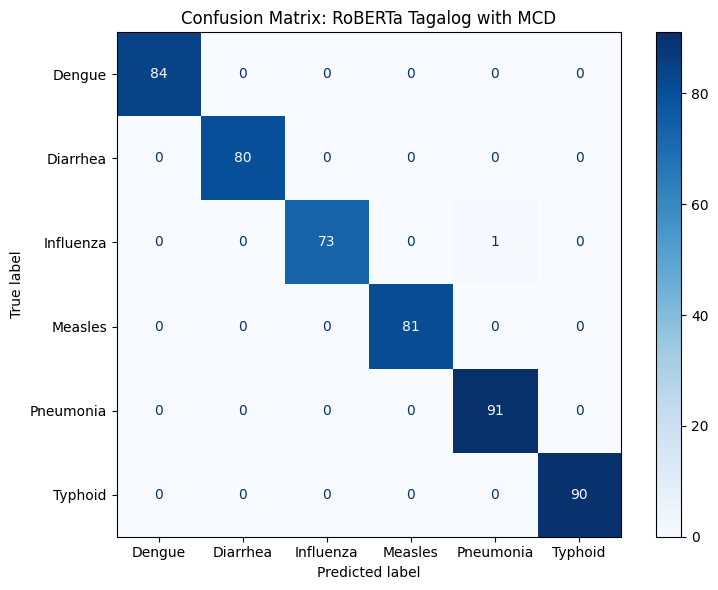

✅ Confusion Matrix (Baseline) saved to 'confusion_matrix_baseline.png'


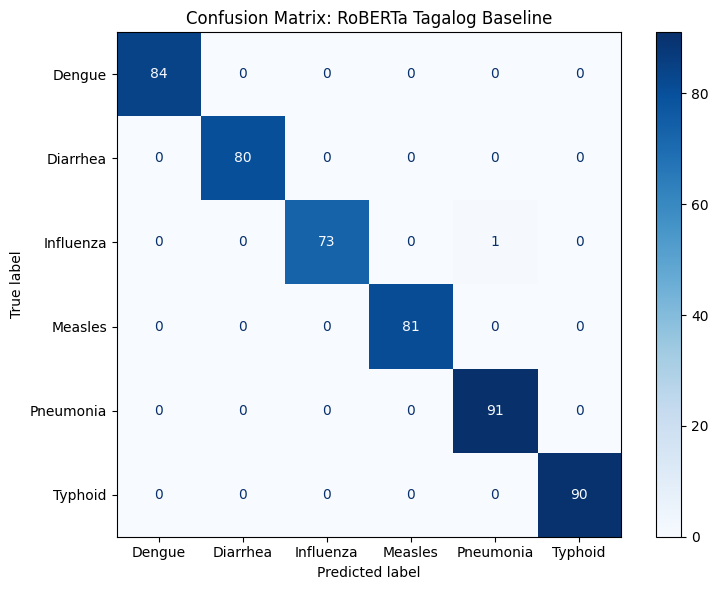

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*80)
print("📈 CONFUSION MATRIX ANALYSIS: MCD vs BASELINE")
print("="*80)

# Ensure true_labels, mcd_predictions, and baseline_predictions are available
# These were generated in the previous comparison cell (y1e11Ci9Sf_y)
# If that cell wasn't run, this cell will fail.

if 'true_labels' not in locals() or 'mcd_predictions' not in locals() or 'baseline_predictions' not in locals():
    print("⚠️  Error: Comparison results (true_labels, mcd_predictions, baseline_predictions) not found.")
    print("   Please run the 'MCD vs Baseline Comparison' cell first.")
else:
    # Get the label names from the model config
    # Use the classifier object which should still be in scope
    if 'classifier' in locals() and hasattr(classifier.model.config, 'id2label'):
        display_labels = [classifier.model.config.id2label[i] for i in sorted(classifier.model.config.id2label.keys())]
    else:
        # Fallback if classifier object is not available or lacks id2label
        print("⚠️  Warning: Could not retrieve label names from classifier object. Using numerical labels.")
        display_labels = sorted(list(np.unique(true_labels))) # Use unique labels found in data


    # 1. Confusion Matrix for MCD
    # Align lengths to avoid inconsistent sample-size errors
    n_eval = min(len(true_labels), len(mcd_predictions), len(baseline_predictions))
    if len(true_labels) != len(mcd_predictions) or len(true_labels) != len(baseline_predictions):
        print(
            f"⚠️  Length mismatch detected "
            f"(true={len(true_labels)}, mcd={len(mcd_predictions)}, baseline={len(baseline_predictions)}). "
            f"Using first {n_eval} samples."
        )

    true_labels = np.asarray(true_labels)[:n_eval]
    mcd_predictions = np.asarray(mcd_predictions)[:n_eval]
    baseline_predictions = np.asarray(baseline_predictions)[:n_eval]

    cm_mcd = confusion_matrix(true_labels, mcd_predictions)
    disp_mcd = ConfusionMatrixDisplay(confusion_matrix=cm_mcd, display_labels=display_labels)

    fig_mcd, ax_mcd = plt.subplots(figsize=(8, 6))
    disp_mcd.plot(cmap=plt.cm.Blues, ax=ax_mcd)
    ax_mcd.set_title('Confusion Matrix: RoBERTa Tagalog with MCD')
    plt.tight_layout()
    plt.savefig('confusion_matrix_mcd.png', dpi=300)
    print("✅ Confusion Matrix (MCD) saved to 'confusion_matrix_mcd.png'")
    plt.show()

    # 2. Confusion Matrix for Baseline
    cm_baseline = confusion_matrix(true_labels, baseline_predictions)
    disp_baseline = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=display_labels)

    fig_baseline, ax_baseline = plt.subplots(figsize=(8, 6))
    disp_baseline.plot(cmap=plt.cm.Blues, ax=ax_baseline)
    ax_baseline.set_title('Confusion Matrix: RoBERTa Tagalog Baseline')
    plt.tight_layout()
    plt.savefig('confusion_matrix_baseline.png', dpi=300)
    print("✅ Confusion Matrix (Baseline) saved to 'confusion_matrix_baseline.png'")
    plt.show()

print("="*80)

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np

print("\n" + "="*80)
print("📋 PER-DISEASE CLASSIFICATION REPORT (MCD)")
print("="*80)

# Ensure we use the correct mapping
current_id2label = id2label if 'id2label' in locals() else {i: str(i) for i in range(6)}
target_names = [str(current_id2label.get(i, i)) for i in sorted(np.unique(true_labels))]

# Generate standard report
report_dict = classification_report(
    true_labels,
    mcd_predictions,
    target_names=target_names,
    output_dict=True
)

# Calculate per-class accuracy using the confusion matrix
cm = confusion_matrix(true_labels, mcd_predictions)
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Convert to DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# Add accuracy column to the disease rows
# (The first N rows correspond to the classes)
N = len(target_names)
accuracy_series = pd.Series(class_accuracy, index=target_names)
df_report.insert(0, 'accuracy', np.nan)
df_report.iloc[:N, 0] = accuracy_series.values

# Display the report with highlighting
styled_report = df_report.iloc[:N, :].style.background_gradient(
    cmap='RdYlGn',
    subset=['accuracy', 'precision', 'recall', 'f1-score']
)
display(styled_report)

print("\nSummary of Aggregate Metrics:")
print(f"   Overall Accuracy: {report_dict['accuracy']:.4f}")
print(f"   Macro Avg F1:     {report_dict['macro avg']['f1-score']:.4f}")
print("="*80)


📋 PER-DISEASE CLASSIFICATION REPORT (MCD)


,accuracy,precision,recall,f1-score,support
Dengue,1.000000,1.000000,1.000000,1.000000,84.000000
Diarrhea,1.000000,1.000000,1.000000,1.000000,80.000000
Influenza,0.986486,1.000000,0.986486,0.993197,74.000000
Measles,1.000000,1.000000,1.000000,1.000000,81.000000
Pneumonia,1.000000,0.989130,1.000000,0.994536,91.000000
Typhoid,1.000000,1.000000,1.000000,1.000000,90.000000



Summary of Aggregate Metrics:
   Overall Accuracy: 0.9980
   Macro Avg F1:     0.9980
